# Laboratorio 4 — Parte 2
## Análisis de modelos usando datos geoespaciales

**Universidad del Valle de Guatemala — CC3084 Data Science — Semestre II 2026**

Modelos de aprendizaje automático para identificar zonas con alta presencia de
cianobacteria en los lagos Atitlán y Amatitlán, a partir de los rásters
Sentinel-2 L2A generados en la Parte I.

La preparación pesada del conjunto de datos (lectura de los 22 rásters y del
caché de bandas) vive en `ml_pipeline.py`, que este notebook importa. Todo lo
demás —modelado, validación, interpretación y mapas— se ejecuta aquí.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# El notebook vive en notebooks/, pero los modulos del proyecto estan en la raiz.
RAIZ = Path.cwd()
if not (RAIZ / "ml_pipeline.py").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import ml_pipeline as mp
from main import LAKES, RESOLUTION

# main.py fija el backend Agg al importarse; se restaura el inline para que
# las figuras queden visibles dentro del notebook.
%matplotlib inline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"

FIGURAS = mp.ML_OUTPUTS / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

# Acumulador de resultados para el informe final.
resultados: dict = {}


def guardar(fig, nombre: str) -> None:
    """Guarda una figura en outputs/ml/figuras y la deja visible en el notebook."""
    fig.savefig(FIGURAS / f"{nombre}.png")


print("Lagos:", ", ".join(l.label for l in LAKES.values()))
print("Resolución del píxel:", RESOLUTION, "m")

Lagos: Lago Atitlán, Lago Amatitlán
Resolución del píxel: 20.0 m


---
# Ejercicio 1. Preparación de los datos para Machine Learning

## 1.1 y 1.2 Construcción del conjunto de datos

Cada fila del conjunto de datos representa **un píxel de agua en una fecha
concreta**. La unidad de observación es por tanto el par (posición, fecha), lo
que permite conservar simultáneamente la dimensión espacial y la temporal que
exige el laboratorio.

Las columnas mínimas requeridas están todas presentes:

| Requisito del enunciado | Columna |
|---|---|
| Coordenadas espaciales | `x`, `y` (EPSG:32615, metros) |
| Fecha de adquisición | `fecha` |
| Lago | `lago` |
| Bandas espectrales | `B03`, `B04`, `B05`, `B08` (reflectancia BOA) |
| NDVI | `ndvi` |
| NDWI | `ndwi` |
| Presencia de cianobacteria | `cyano_chla_proxy` (mg/m³) y `ndci` |

Las bandas se almacenan como **reflectancia**, no como número digital: para la
línea base de procesamiento 04.00 de Sentinel-2 la conversión es
`(DN − 1000) / 10000`, según `BOA_ADD_OFFSET` y `BOA_QUANTIFICATION_VALUE`.

In [2]:
df = mp.cargar_dataset()
print(f"{len(df):,} observaciones × {df.shape[1]} variables")
df.head()

3,437,341 observaciones × 24 variables


,lago,fecha,x,y,fila,columna,B03,B04,B05,B08,...,razon_b03_b08,b03_textura,b03_anomalia,b08_textura,dist_orilla_m,mes,doy_sin,doy_cos,temporada_lluviosa,alta_cianobacteria
0,Lago Atitlán,2025-01-18,697150.0,1631250.0,21,849,0.0285,0.0209,0.0265,0.0321,...,0.887850,0.012167,0.004020,0.021894,20.0,1,0.304719,0.952442,0,0
1,Lago Atitlán,2025-01-18,697170.0,1631250.0,21,850,0.0323,0.0262,0.0352,0.0386,...,0.836788,0.014472,0.005071,0.032695,20.0,1,0.304719,0.952442,0,0
2,Lago Atitlán,2025-01-18,697190.0,1631250.0,21,851,0.0408,0.0365,0.0521,0.0588,...,0.693878,0.017157,0.006478,0.059486,20.0,1,0.304719,0.952442,0,0
3,Lago Atitlán,2025-01-18,697210.0,1631250.0,21,852,0.0514,0.0488,0.0716,0.1007,...,0.510427,0.018424,0.011455,0.089464,20.0,1,0.304719,0.952442,0,0
4,Lago Atitlán,2025-01-18,697230.0,1631250.0,21,853,0.0677,0.0632,0.1063,0.2079,...,0.325637,0.017691,0.024823,0.109563,20.0,1,0.304719,0.952442,0,0


## 1.3 Limpieza: qué observaciones se eliminaron

El filtrado se hereda de la Parte I y opera en tres niveles:

1. **Fuera del lago.** Solo entran los píxeles de la máscara permanente de cada
   lago, obtenida por consenso temporal de SCL/NDWI, conservando el componente
   de agua mayor y erosionando 20 m del borde para eliminar píxeles mixtos de
   costa.
2. **Nubes, sombras, nieve y píxeles saturados.** Se rechazan las clases 0, 1,
   3, 8, 9, 10 y 11 de la banda de clasificación de escena (SCL).
3. **NoData y valores no utilizables.** Se exige número digital positivo en las
   cuatro bandas y denominador no nulo en el NDCI.

El resultado coincide exactamente, fecha por fecha, con la columna
`pixeles_validos` del resumen de la Parte I: es el mismo universo de datos, no
una reconstrucción aproximada.

In [3]:
verificacion = pd.read_csv(mp.OUTPUTS / "resumen_temporal.csv")
verificacion["fecha"] = pd.to_datetime(verificacion["fecha"])
conteo_nb = df.groupby(["lago", "fecha"], observed=True).size().rename("filas_dataset")
cruce = verificacion.merge(
    conteo_nb, left_on=["lago", "fecha"], right_index=True, how="left"
)
print("¿Coincide el conteo con la Parte I en las 22 fechas?",
      bool((cruce["pixeles_validos"] == cruce["filas_dataset"]).all()))
cruce[["lago", "fecha", "pixeles_validos", "filas_dataset", "cobertura_valida_pct"]].head()

¿Coincide el conteo con la Parte I en las 22 fechas? True


,lago,fecha,pixeles_validos,filas_dataset,cobertura_valida_pct
0,Lago Amatitlán,2025-01-28,35430,35430,99.991533
1,Lago Amatitlán,2025-04-15,35433,35433,100.000000
2,Lago Amatitlán,2025-04-28,35432,35432,99.997178
3,Lago Amatitlán,2025-11-24,35430,35430,99.991533
4,Lago Amatitlán,2026-01-08,35432,35432,99.997178


El enmascaramiento no es uniforme entre fechas. La cobertura válida va del
100 % en las escenas despejadas al 23.8 % en la fecha **2025-01-18 de
Atitlán**, la más nublada de las veintidós. Esa fecha recibe un examen
específico en el inciso 1.5.

In [4]:
resumen = mp.resumen_dataset(df)

## 1.4 Número de observaciones, variables, tipos y faltantes

In [5]:
print(f"TOTAL: {len(df):,} observaciones\n")
print("Observaciones por lago:")
print(resumen["por_lago"].to_string(float_format=lambda v: f"{v:,.2f}"))

TOTAL: 3,437,341 observaciones

Observaciones por lago:
                observaciones  porcentaje
lago                                     
Lago Amatitlán         386822       11.25
Lago Atitlán          3050519       88.75


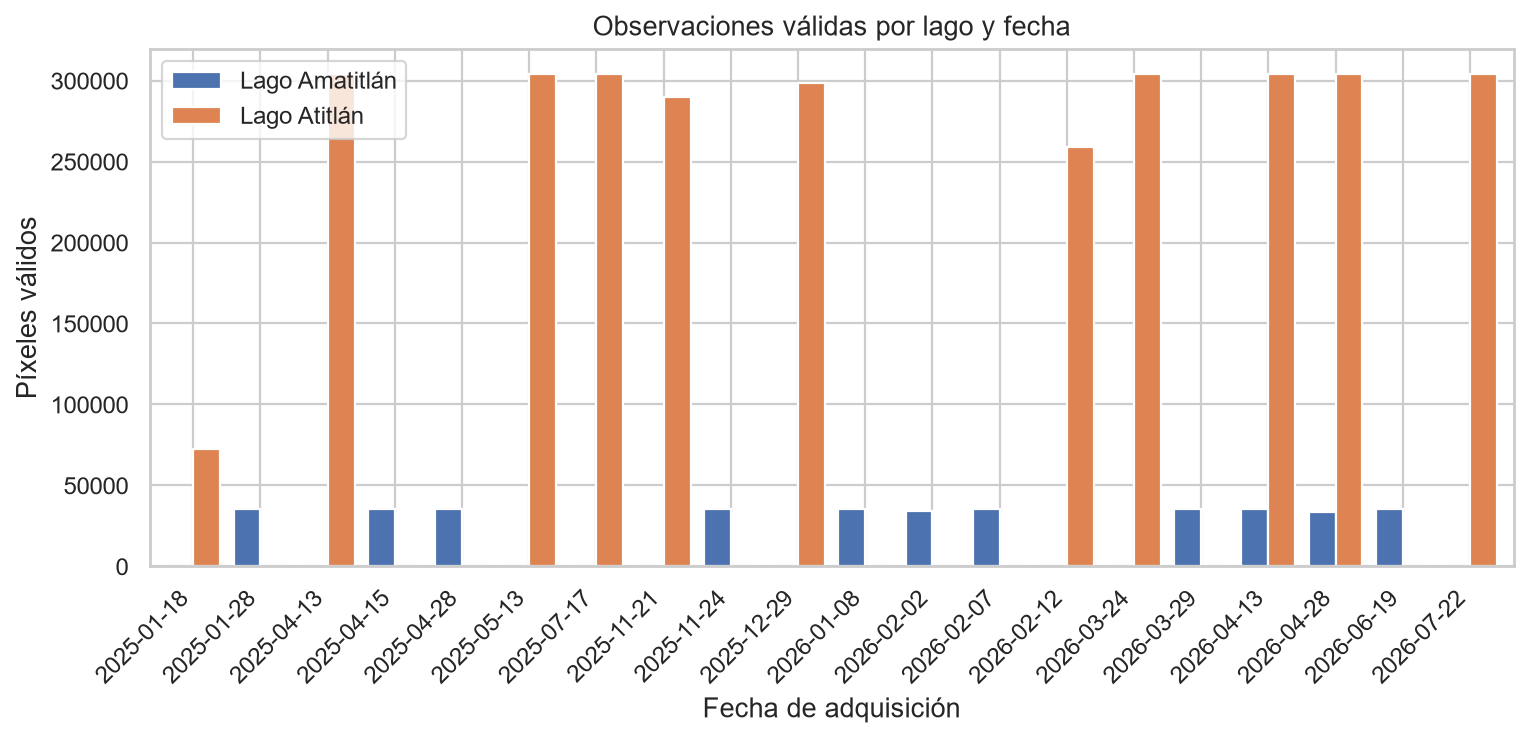

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
pivote = resumen["por_fecha"].pivot(index="fecha", columns="lago", values="observaciones")
pivote.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Observaciones válidas por lago y fecha")
ax.set_xlabel("Fecha de adquisición")
ax.set_ylabel("Píxeles válidos")
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in pivote.index], rotation=45, ha="right")
ax.legend(title="")
guardar(fig, "obs_por_fecha")
plt.show()

Atitlán aporta el 88.6 % de las observaciones simplemente porque es **8.6 veces
más grande** (121.8 km² contra 14.2 km²). Este desbalance geográfico no es un
defecto del muestreo sino un hecho físico, pero condiciona los modelos
agrupados y es una de las razones por las que el Ejercicio 7 evalúa cada lago
por separado.

In [7]:
print("Variables, tipo, rol y porcentaje de valores faltantes:")
resumen["variables"]

Variables, tipo, rol y porcentaje de valores faltantes:


,tipo,faltantes_pct,rol
lago,category,0.000000,identificador
fecha,datetime64[ns],0.000000,identificador
x,float64,0.000000,identificador
y,float64,0.000000,identificador
fila,int32,0.000000,identificador
columna,int32,0.000000,identificador
B03,float32,0.000000,predictora
B04,float32,0.000000,excluida (fuga)
B05,float32,0.000000,excluida (fuga)
B08,float32,0.000000,predictora


Solo tres variables tienen faltantes, y son faltantes **declarados, no
accidentales**:

- `ndvi` y `ndwi` (2.49 %): sobre agua muy oscura el infrarrojo cercano puede
  quedar ligeramente negativo tras la corrección atmosférica. El cociente deja
  de ser interpretable, pero eso **no invalida el NDCI**, que usa rojo y
  borde-rojo. La Parte I ya aplicaba esta validez por índice; aquí esos casos
  se marcan como `NaN` en lugar de arrastrar un `-9999` disfrazado de dato.
- `razon_b03_b08` (0.56 %): se anula cuando el NIR está demasiado próximo a
  cero para dividir.

Ninguna variable supera el 3 % de faltantes, así que se imputan por mediana en
el preprocesamiento en lugar de descartar filas.

## 1.5 Análisis exploratorio

In [8]:
descriptivas = df[list(mp.PREDICTORES) + ["cyano_chla_proxy"]].describe().T
descriptivas.to_csv(mp.ML_OUTPUTS / "estadisticas_descriptivas.csv")
descriptivas

,count,mean,std,min,25%,50%,75%,max
B03,3437341.0,0.023835,0.017045,0.002000,0.013000,0.020200,0.026300,0.302900
B08,3437341.0,0.012431,0.020500,-0.028000,0.003600,0.007800,0.014500,0.662400
ndwi,3351699.0,0.431281,0.201528,-0.854545,0.291845,0.423221,0.555556,0.996710
razon_b03_b08,3418188.0,2.940068,5.247709,-50.000000,1.783505,2.438775,3.451613,50.000000
b03_textura,3437341.0,0.001186,0.003027,0.000000,0.000278,0.000425,0.000983,0.085036
b03_anomalia,3437341.0,0.000024,0.002462,-0.076288,-0.000300,-0.000020,0.000252,0.184750
b08_textura,3437341.0,0.001908,0.008575,0.000000,0.000206,0.000382,0.000991,0.201635
dist_orilla_m,3437341.0,1206.646729,961.037720,20.000000,360.000000,983.869934,1902.629761,3672.710205
doy_sin,3437341.0,0.416063,0.593018,-0.638384,-0.261414,0.674069,0.979857,0.998377
doy_cos,3437341.0,-0.040010,0.688201,-0.976509,-0.657221,-0.199702,0.738668,0.999251


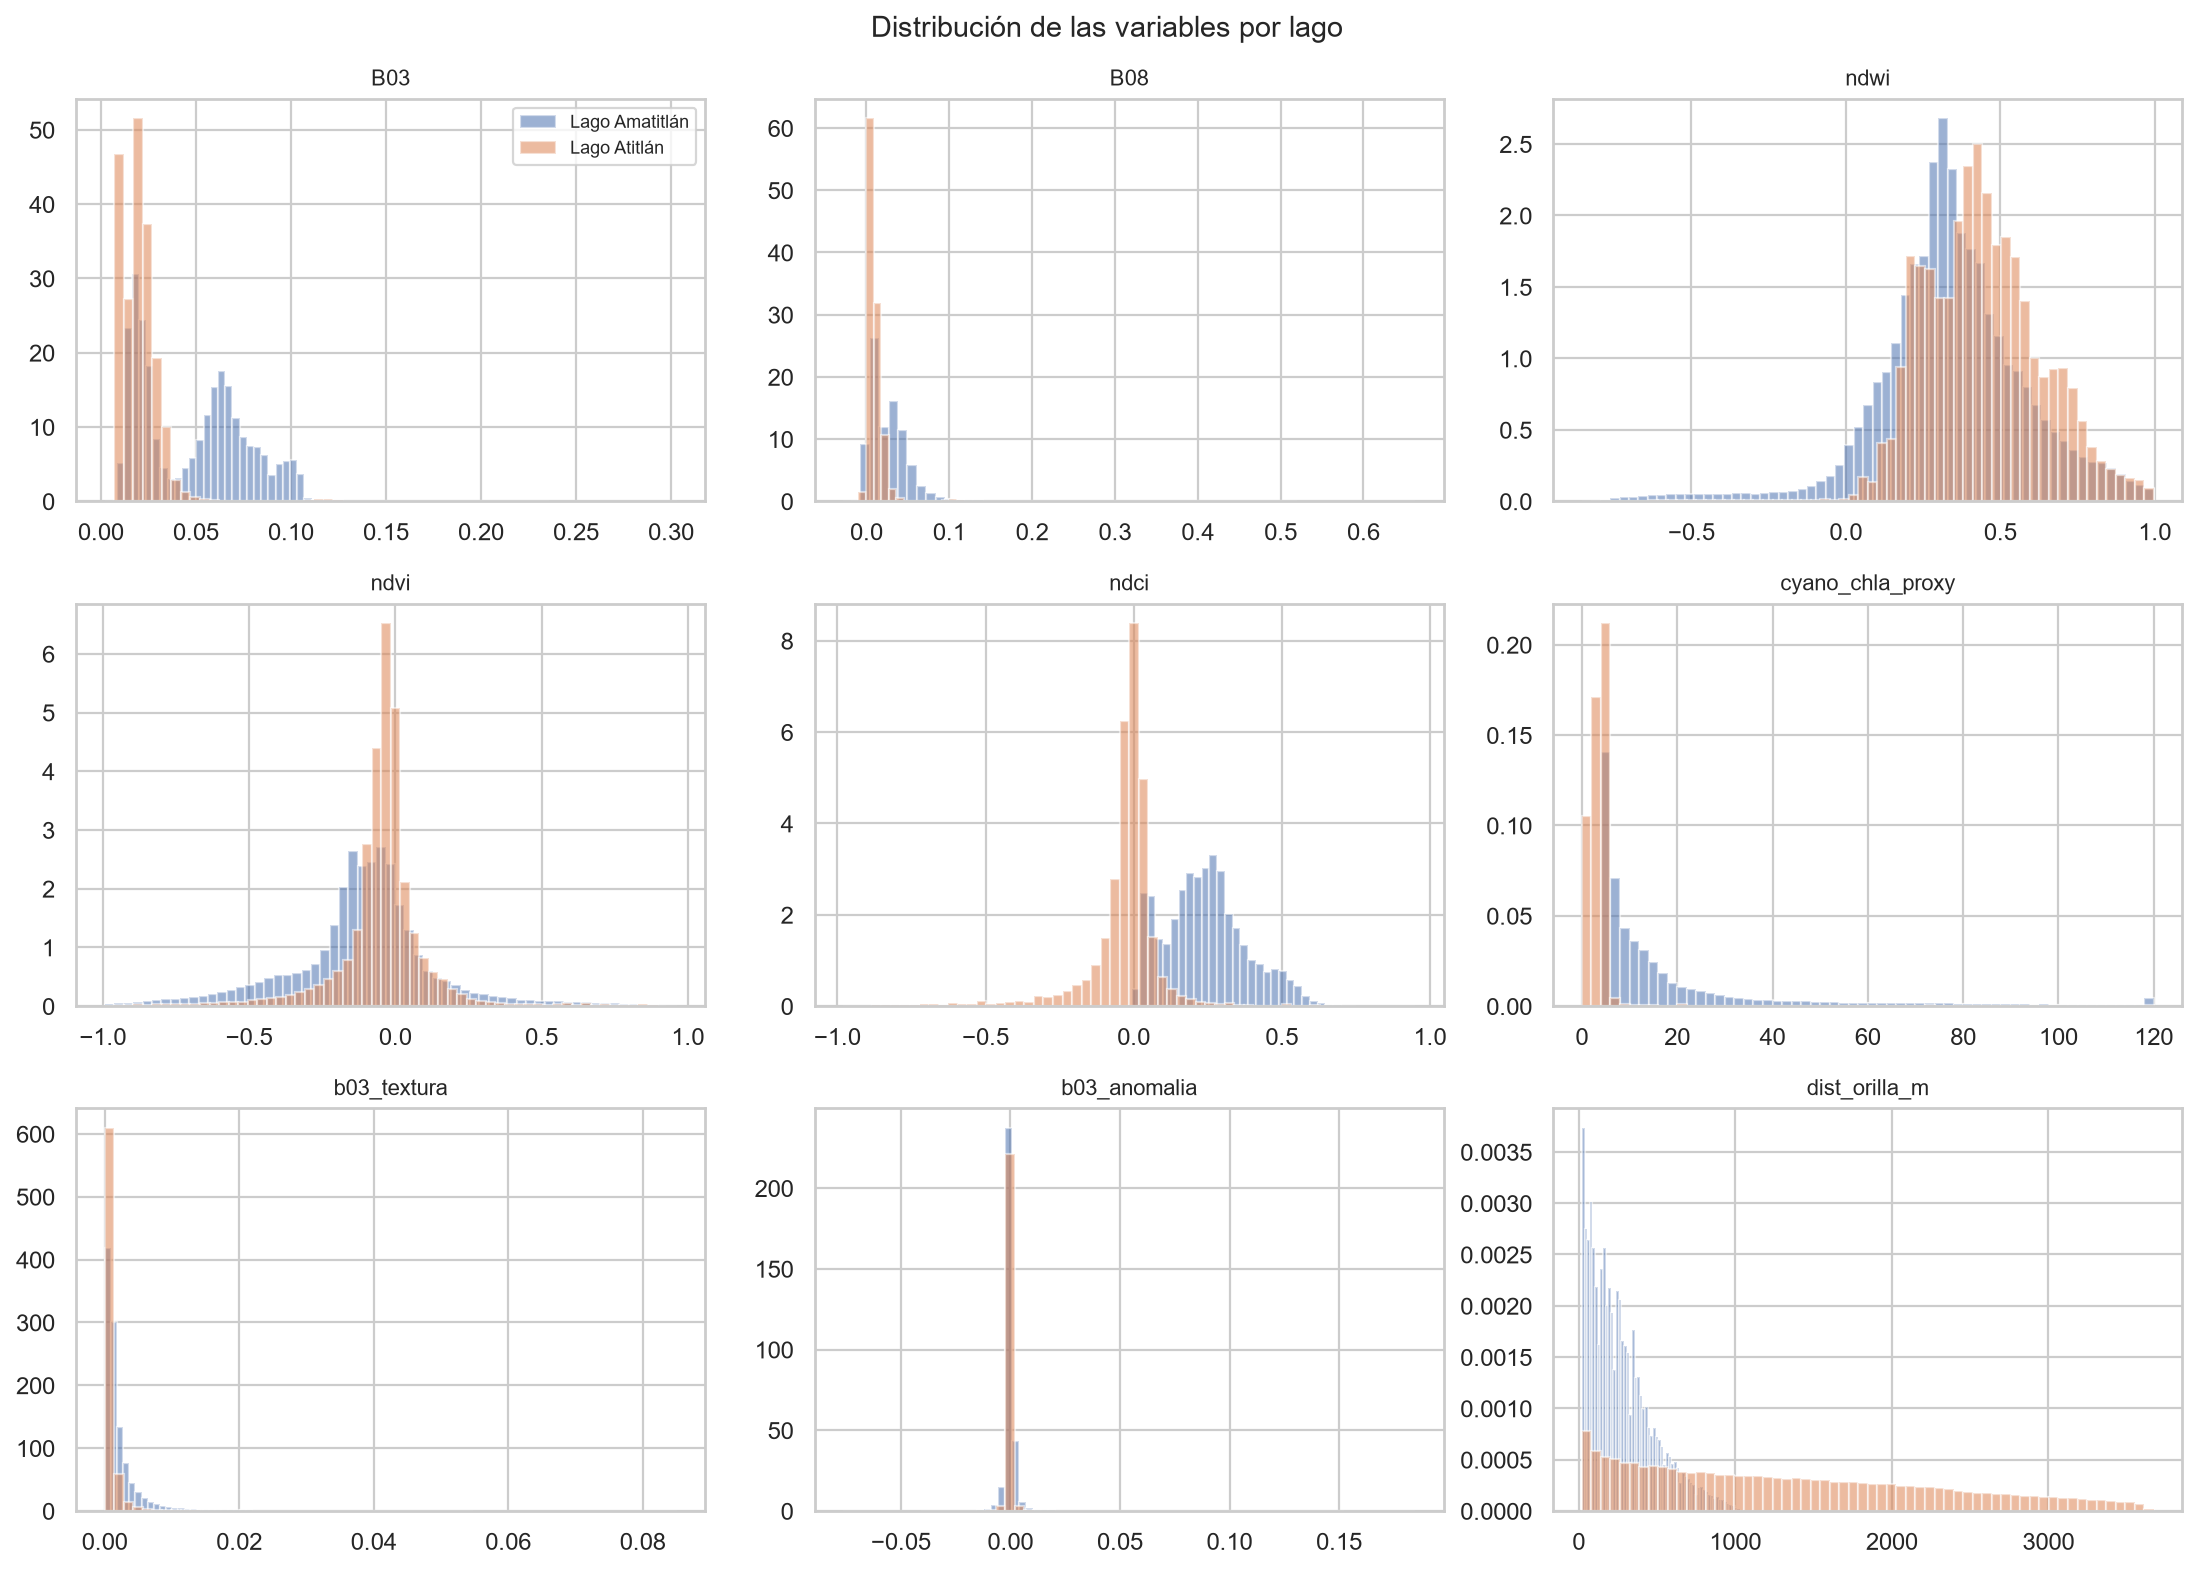

In [9]:
columnas_eda = ["B03", "B08", "ndwi", "ndvi", "ndci", "cyano_chla_proxy",
                "b03_textura", "b03_anomalia", "dist_orilla_m"]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), columnas_eda):
    for lago, sub in df.groupby("lago", observed=True):
        datos = sub[col].dropna()
        if col == "cyano_chla_proxy":
            datos = datos.clip(upper=120)
        ax.hist(datos, bins=60, alpha=0.55, label=str(lago), density=True)
    ax.set_title(col, fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Distribución de las variables por lago", fontsize=13)
fig.tight_layout()
guardar(fig, "eda_distribuciones")
plt.show()

Las distribuciones separan a los dos lagos con claridad. Amatitlán presenta
reflectancia verde (`B03`) más alta y una cola larga de clorofila-a que Atitlán
no tiene: el histograma de `cyano_chla_proxy` de Atitlán se concentra por
debajo de 10 mg/m³, mientras que Amatitlán se extiende más allá del recorte de
120 mg/m³ del gráfico.

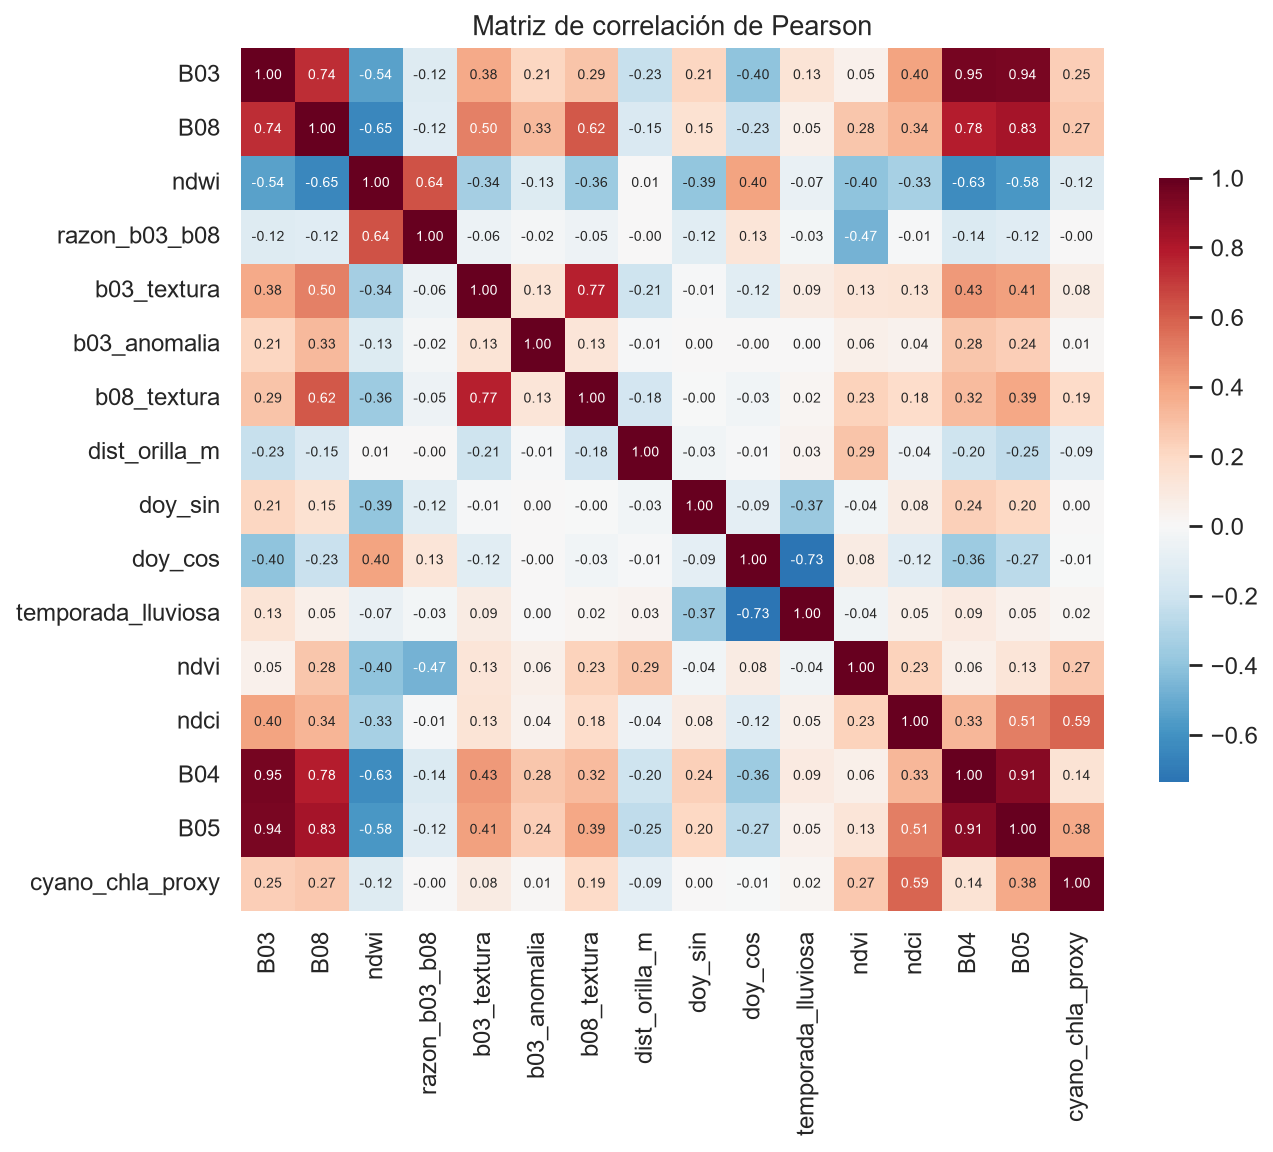

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
correlaciones = df[list(mp.PREDICTORES) + ["ndvi", "ndci", "B04", "B05",
                                           "cyano_chla_proxy"]].corr()
sns.heatmap(correlaciones, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, square=True, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Matriz de correlación de Pearson")
guardar(fig, "eda_correlacion")
plt.show()

La matriz confirma el riesgo de fuga que se discute en el Ejercicio 2.5:
`ndci` correlaciona casi perfectamente con `cyano_chla_proxy` —es su único
insumo— y `B05` y `B04` le siguen de cerca. Entre los predictores admitidos,
la correlación más alta con la respuesta la tiene `B03`, lo que es coherente
con la física del problema: las natas de cianobacteria elevan la reflectancia
en el verde.

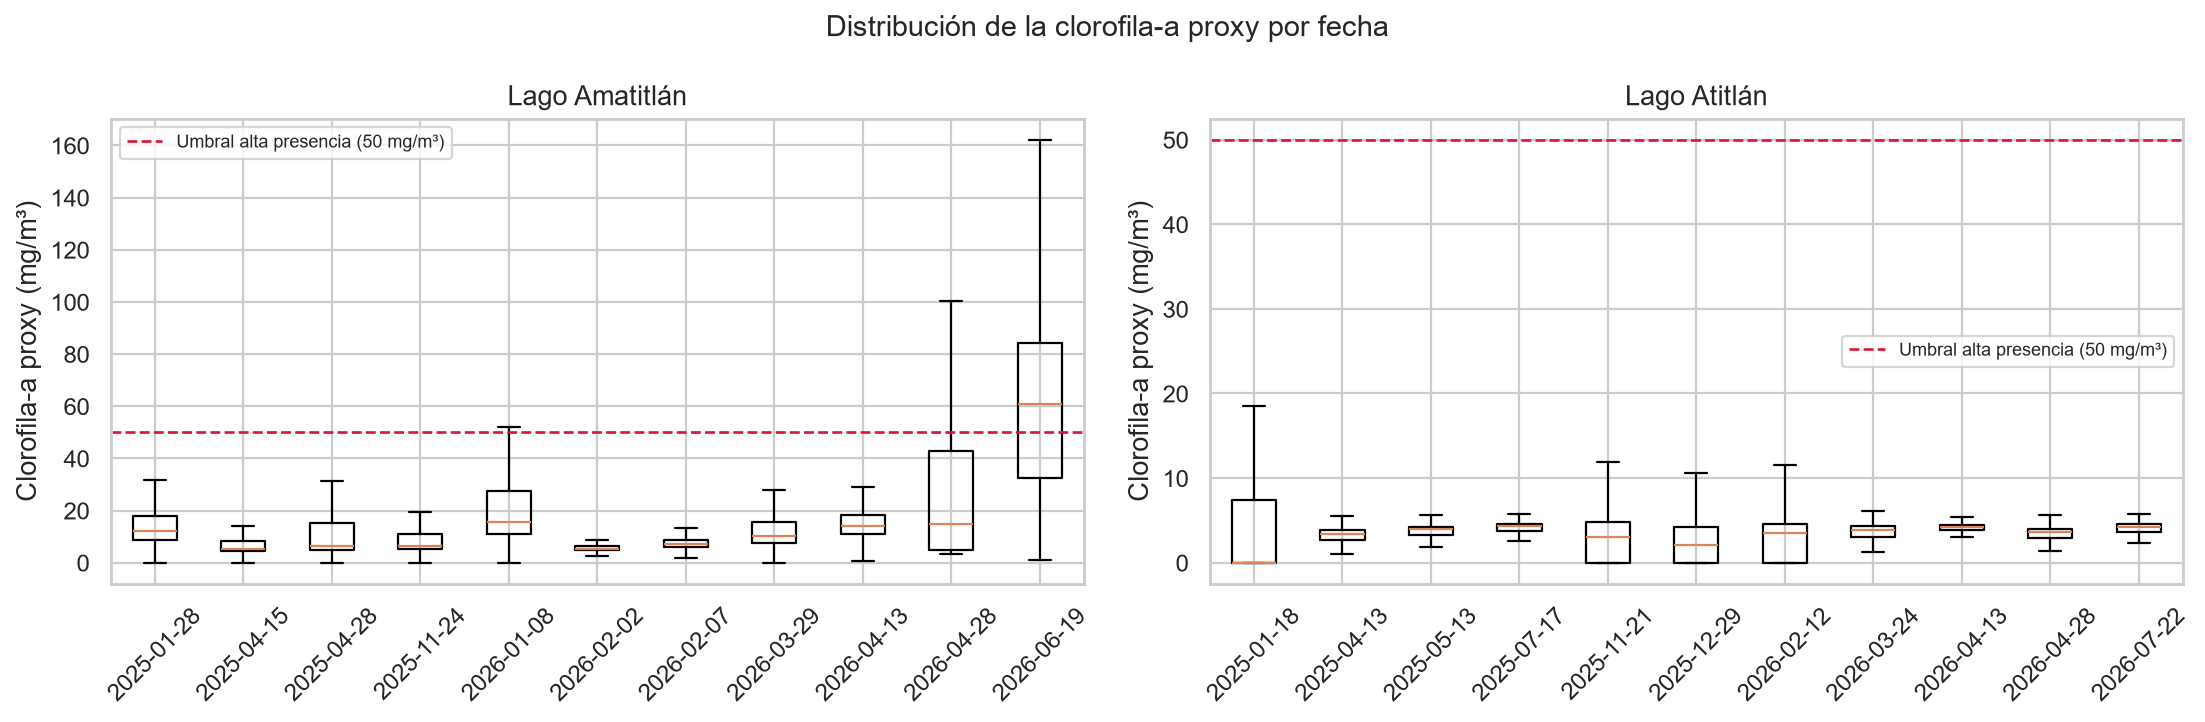

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=False)
for ax, (lago, sub) in zip(axes, df.groupby("lago", observed=True)):
    orden = sorted(sub["fecha"].unique())
    ax.boxplot([sub.loc[sub["fecha"] == f, "cyano_chla_proxy"].values for f in orden],
               tick_labels=[pd.Timestamp(f).strftime("%Y-%m-%d") for f in orden],
               showfliers=False)
    ax.axhline(mp.THRESHOLD_ALTA_PRESENCIA, color="crimson", ls="--", lw=1.2,
               label="Umbral alta presencia (50 mg/m³)")
    ax.set_title(str(lago))
    ax.set_ylabel("Clorofila-a proxy (mg/m³)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
fig.suptitle("Distribución de la clorofila-a proxy por fecha", fontsize=13)
fig.tight_layout()
guardar(fig, "eda_boxplot_fecha")
plt.show()

La escala vertical de cada panel habla por sí sola: en Atitlán la caja completa
de todas las fechas cae muy por debajo de la línea de 50 mg/m³, mientras que en
Amatitlán hay fechas cuyo bigote superior la cruza holgadamente.

Salvo por una excepción que el gráfico deja ver de inmediato: **2025-01-18 en
Atitlán** se sale por completo del comportamiento de su propio lago.

### Control de calidad por fecha: una escena sospechosa

Antes de modelar conviene verificar que ninguna fecha esté aportando señal
espuria. El contraste entre la nubosidad de cada escena y la intensidad que
reporta es revelador.

In [12]:
control = (df.groupby(["lago", "fecha"], observed=True)
             .agg(media_chla=("cyano_chla_proxy", "mean"),
                  p90_chla=("cyano_chla_proxy", lambda s: s.quantile(0.90)),
                  positivos_pct=("alta_cianobacteria", lambda s: 100 * s.mean()),
                  observaciones=("cyano_chla_proxy", "size"))
             .reset_index())
control = control.merge(
    verificacion[["lago", "fecha", "cobertura_valida_pct"]],
    on=["lago", "fecha"], how="left")
control.loc[control["lago"] == "Lago Atitlán"].round(2).to_string(index=False)

'        lago      fecha  media_chla  p90_chla  positivos_pct  observaciones  cobertura_valida_pct\nLago Atitlán 2025-01-18   21.290001     72.78          12.52          72372                 23.78\nLago Atitlán 2025-04-13    3.090000      4.07           0.00         304392                100.00\nLago Atitlán 2025-05-13    3.550000      4.44           0.01         304387                100.00\nLago Atitlán 2025-07-17    3.960000      4.77           0.05         304294                 99.97\nLago Atitlán 2025-11-21    3.180000      5.72           0.22         289960                 95.26\nLago Atitlán 2025-12-29    2.350000      4.84           0.09         298610                 98.10\nLago Atitlán 2026-02-12    3.100000      5.05           0.18         259086                 85.11\nLago Atitlán 2026-03-24    3.490000      4.55           0.00         304390                100.00\nLago Atitlán 2026-04-13    3.950000      4.60           0.00         304254                 99.95\nLago Atit

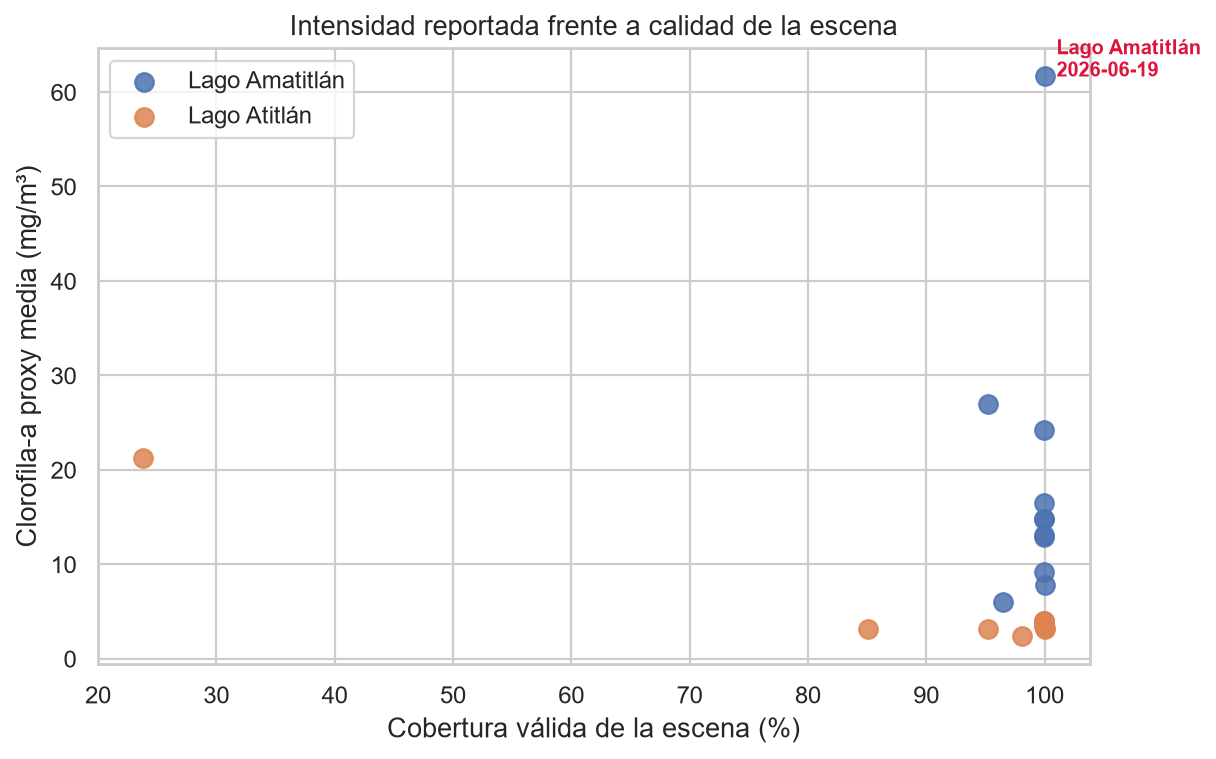

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for lago, sub in control.groupby("lago", observed=True):
    ax.scatter(sub["cobertura_valida_pct"], sub["media_chla"], s=70,
               label=str(lago), alpha=0.85)
sospechosa = control.loc[control["media_chla"].idxmax()]
ax.annotate(f"  {sospechosa['lago']}\n  {pd.Timestamp(sospechosa['fecha']).date()}",
            (sospechosa["cobertura_valida_pct"], sospechosa["media_chla"]),
            fontsize=9, color="crimson", weight="bold")
ax.set_xlabel("Cobertura válida de la escena (%)")
ax.set_ylabel("Clorofila-a proxy media (mg/m³)")
ax.set_title("Intensidad reportada frente a calidad de la escena")
ax.legend()
guardar(fig, "control_calidad_escenas")
plt.show()

El diagnóstico es inequívoco. La escena **2025-01-18 de Atitlán** es a la vez
la más nublada del conjunto (23.8 % de cobertura válida) y la que reporta una
media de 21.3 mg/m³ frente a los 2.4–4.0 mg/m³ de las otras diez fechas del
mismo lago: entre **seis y quince veces más alta**, con un percentil 90 de 72.8
contra 4.1–5.7. Concentra por sí sola el 83 % de todas las observaciones
positivas de Atitlán.

Ningún proceso limnológico produce un salto así en un lago profundo y
oligotrófico para volver al valor de base tres meses después. Lo que queda es
**contaminación residual**: cirros delgados, penumbra de nube y aerosoles que
la banda SCL no alcanza a clasificar y que elevan la reflectancia en el rojo y
el borde-rojo, justo las dos bandas del NDCI.

La consecuencia de conservarla sería grave y silenciosa: el modelo aprendería a
reconocer *nubes delgadas* etiquetadas como floración, y el Experimento A del
Ejercicio 7 —entrenar en Atitlán— quedaría construido casi enteramente sobre
ese artefacto. Se excluye del conjunto de modelado.

## 1.6 Decisiones de preparación y limpieza

1. **Unidad de observación píxel-fecha.** Permite tratar el problema como
   clasificación supervisada conservando coordenadas y fecha, requisito
   explícito del enunciado y condición necesaria para la validación espacial
   del Ejercicio 6.
2. **Reflectancia en lugar de número digital.** Sin la conversión
   `(DN − 1000)/10000` las bandas no serían comparables con los índices ni con
   la literatura, y su escala (miles) desestabilizaría a la regresión
   logística.
3. **Validez por índice y no global.** Un píxel puede tener NDCI válido y NDVI
   inválido. Descartar la fila entera habría eliminado un 2.5 % de
   observaciones perfectamente utilizables para la variable respuesta; en su
   lugar el faltante se declara como `NaN`.
4. **Sin recorte de valores extremos.** La clorofila-a ya viene acotada al
   intervalo físico 0–500 mg/m³ del script original. Los valores altos son
   justamente la señal de interés: eliminarlos como *outliers* borraría las
   floraciones.
5. **Erosión de 20 m en el borde del lago.** Los píxeles de orilla mezclan agua
   y vegetación terrestre, y esa vegetación eleva artificialmente los índices
   de clorofila. Se prefiere perder una franja delgada a introducir falsos
   positivos sistemáticos en el contorno.
6. **Exclusión de la escena 2025-01-18 de Atitlán.** Es la única fecha
   descartada por completo, y la decisión se toma con criterio explícito y
   verificable: cobertura válida por debajo del 25 % **y** una media más de
   seis veces superior a la de cualquier otra fecha del mismo lago. Se prefiere
   perder el 2 % de las observaciones a entrenar sobre un artefacto atmosférico.

In [14]:
ESCENA_DESCARTADA = ("Lago Atitlán", pd.Timestamp("2025-01-18"))

df_bruto = df
descarte = (df["lago"] == ESCENA_DESCARTADA[0]) & (df["fecha"] == ESCENA_DESCARTADA[1])
df = df.loc[~descarte].reset_index(drop=True)

print(f"Conjunto bruto:     {len(df_bruto):,} observaciones")
print(f"Escena descartada:  {int(descarte.sum()):,} observaciones "
      f"({100*descarte.mean():.2f} %)")
print(f"Conjunto de trabajo: {len(df):,} observaciones en "
      f"{df.groupby(['lago','fecha'], observed=True).ngroups} escenas")
print(f"\nPrevalencia antes:   {100*df_bruto['alta_cianobacteria'].mean():.2f} %")
print(f"Prevalencia después: {100*df['alta_cianobacteria'].mean():.2f} %")
print("\nPositivos por lago tras el descarte:")
print(df.groupby("lago", observed=True)["alta_cianobacteria"]
        .agg(["sum", "mean"]).rename(columns={"sum": "positivos", "mean": "prevalencia"}))

Conjunto bruto:     3,437,341 observaciones
Escena descartada:  72,372 observaciones (2.11 %)
Conjunto de trabajo: 3,364,969 observaciones en 21 escenas



Prevalencia antes:   1.37 %
Prevalencia después: 1.13 %

Positivos por lago tras el descarte:
                positivos  prevalencia
lago                                  
Lago Amatitlán      36334     0.093930
Lago Atitlán         1820     0.000611


Tras el descarte, Atitlán conserva 1 820 observaciones positivas: pocas, pero
**reales**. Ese número modesto es en sí mismo un resultado —Atitlán no
experimenta floraciones densas en el período estudiado— y condiciona lo que
cabe esperar del Experimento A del Ejercicio 7.

---
# Ejercicio 2. Construcción de la variable respuesta

## 2.1 y 2.2 Definición y justificación del punto de corte

$$\text{alta\_cianobacteria} = \begin{cases} 1 & \text{si } \text{Chl-a} \geq 50\ \text{mg/m}^3 \\ 0 & \text{en caso contrario} \end{cases}$$

El corte de **50 mg/m³ (equivalente a 50 µg/L)** no es arbitrario: corresponde
al **Alert Level 2** del marco de alerta para cianobacterias en aguas
recreativas de la Organización Mundial de la Salud (Chorus & Welker, 2021,
*Toxic Cyanobacteria in Water*, 2ª ed., cap. 5). Ese nivel marca el punto en
que la autoridad sanitaria debe pasar de la vigilancia a la **acción**:
advertencia al público, restricción del contacto con el agua y muestreo de
toxinas.

La escala completa que sigue la OMS para clorofila-a en un cuerpo de agua
dominado por cianobacterias es:

| Nivel | Clorofila-a | Interpretación sanitaria |
|---|---|---|
| Vigilancia | < 10 mg/m³ | Riesgo bajo; monitoreo de rutina |
| Alert Level 1 | 10 – 50 mg/m³ | Floración incipiente; aumentar frecuencia de muestreo |
| **Alert Level 2** | **≥ 50 mg/m³** | **Floración establecida; restringir uso recreativo** |

El corte se eligió además por dos razones prácticas. Primero, **es el mismo
umbral usado en la Parte I** para reportar el porcentaje de área en alerta
alta, de modo que ambas partes del laboratorio son directamente comparables.
Segundo, un corte más bajo (10 mg/m³) haría que casi la mitad de las
observaciones de Amatitlán fueran positivas y prácticamente ninguna de Atitlán,
convirtiendo el problema en un detector de lago en vez de un detector de
floración.

**Referencias:**

- Chorus, I., & Welker, M. (Eds.). (2021). *Toxic Cyanobacteria in Water: A
  Guide to Their Public Health Consequences, Monitoring and Management* (2nd
  ed.). CRC Press, en nombre de la Organización Mundial de la Salud.
- World Health Organization. (2021). *Guidelines on Recreational Water Quality.
  Volume 1: Coastal and Fresh Waters*. Ginebra: OMS.
- Mishra, S., & Mishra, D. R. (2012). Normalized difference chlorophyll index:
  A novel model for remote estimation of chlorophyll-a concentration in
  turbid productive waters. *Remote Sensing of Environment, 117*, 394–406.

In [15]:
print(f"Umbral aplicado: {mp.THRESHOLD_ALTA_PRESENCIA:.0f} mg/m³")
df["alta_cianobacteria"].value_counts().rename({0: "0 = baja/ausente", 1: "1 = alta"})

Umbral aplicado: 50 mg/m³


alta_cianobacteria
0 = baja/ausente    3326815
1 = alta              38154
Name: count, dtype: int64

## 2.3 Distribución de la respuesta: global, por lago y por fecha

In [16]:
tasa_global = 100 * df["alta_cianobacteria"].mean()
por_lago = 100 * df.groupby("lago", observed=True)["alta_cianobacteria"].mean()
print(f"Prevalencia global de alta presencia: {tasa_global:.2f} %\n")
print("Prevalencia por lago (%):")
print(por_lago.to_string(float_format=lambda v: f"{v:.2f}"))

Prevalencia global de alta presencia: 1.13 %

Prevalencia por lago (%):
lago
Lago Amatitlán   9.39
Lago Atitlán     0.06


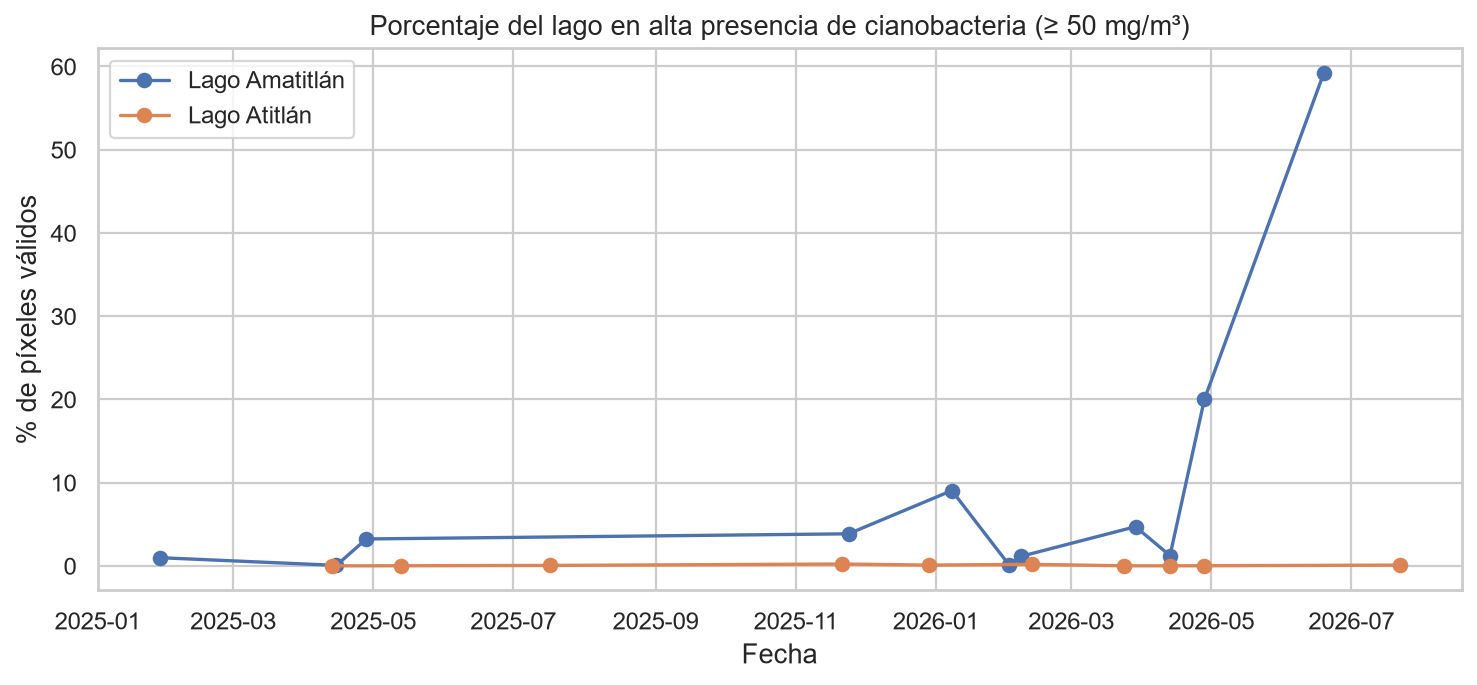

lago,Lago Amatitlán,Lago Atitlán
fecha,,
2025-01-28,0.98,NaN
2025-04-13,NaN,0.00
2025-04-15,0.05,NaN
2025-04-28,3.23,NaN
2025-05-13,NaN,0.01
2025-07-17,NaN,0.05
2025-11-21,NaN,0.22
2025-11-24,3.84,NaN
2025-12-29,NaN,0.09


In [17]:
por_fecha = (df.groupby(["lago", "fecha"], observed=True)["alta_cianobacteria"]
             .mean().mul(100).rename("prevalencia_pct").reset_index())

fig, ax = plt.subplots(figsize=(11, 4.4))
for lago, sub in por_fecha.groupby("lago", observed=True):
    ax.plot(sub["fecha"], sub["prevalencia_pct"], marker="o", label=str(lago))
ax.set_title("Porcentaje del lago en alta presencia de cianobacteria (≥ 50 mg/m³)")
ax.set_ylabel("% de píxeles válidos")
ax.set_xlabel("Fecha")
ax.legend()
guardar(fig, "respuesta_por_fecha")
plt.show()

por_fecha.to_csv(mp.ML_OUTPUTS / "prevalencia_por_fecha.csv", index=False)
por_fecha.pivot(index="fecha", columns="lago", values="prevalencia_pct").round(2)

La serie deja ver que la clase positiva **no está repartida de manera uniforme
en el tiempo**: en Amatitlán se concentra en unas pocas fechas —con un máximo
el 19 de junio de 2026, cuando cerca del 59 % del lago cruza el umbral— y en
Atitlán es casi inexistente salvo repuntes menores. Esta concentración temporal
es exactamente el motivo por el que una validación puramente aleatoria resulta
optimista, como se comprueba en el Ejercicio 6.

## 2.4 Desbalance de clases y sus consecuencias

Negativos: 3,326,815   Positivos: 38,154
Razón de desbalance: 87.2 a 1  (1.13 % positivos)


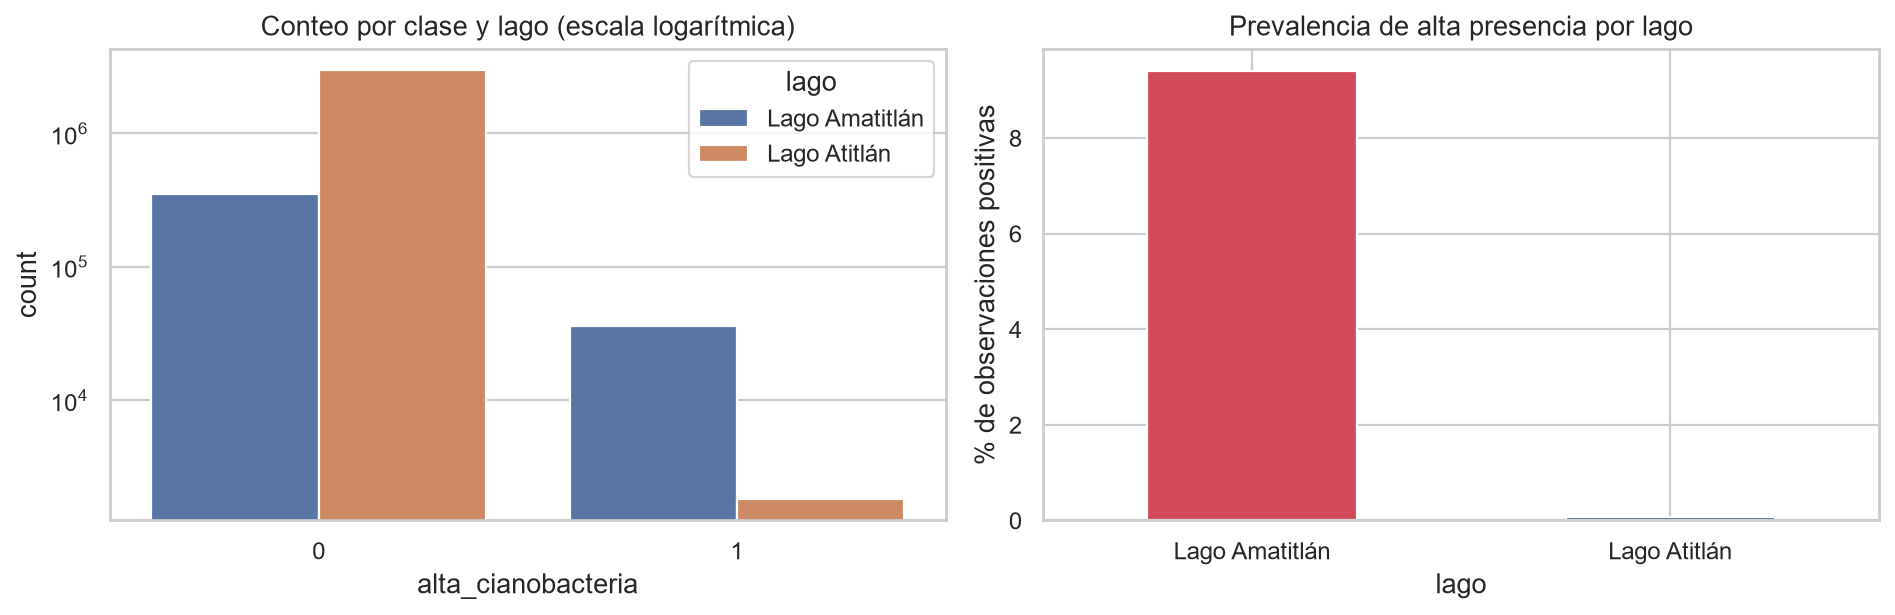

In [18]:
conteo = df["alta_cianobacteria"].value_counts()
razon = conteo[0] / conteo[1]
print(f"Negativos: {conteo[0]:,}   Positivos: {conteo[1]:,}")
print(f"Razón de desbalance: {razon:.1f} a 1  ({100*conteo[1]/len(df):.2f} % positivos)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="alta_cianobacteria", hue="lago", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Conteo por clase y lago (escala logarítmica)")
axes[0].set_xlabel("alta_cianobacteria")
por_lago.plot(kind="bar", ax=axes[1], color=["#d1495b", "#30638e"])
axes[1].set_title("Prevalencia de alta presencia por lago")
axes[1].set_ylabel("% de observaciones positivas")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
guardar(fig, "desbalance_clases")
plt.show()

El conjunto está **fuertemente desbalanceado: 1.13 % de positivos, una razón
cercana a 87 a 1**. Y el desbalance es además profundamente asimétrico entre
lagos: Amatitlán aporta el **95 % de todos los positivos con apenas el 11.5 %
de las observaciones**. Atitlán, tras descartar la escena contaminada, queda
con una prevalencia de 0.06 %.

Consecuencias sobre el entrenamiento y la evaluación:

- **El *accuracy* deja de ser informativo.** Un clasificador que responda
  siempre "0" alcanza 98.9 % de exactitud sin detectar una sola floración. Por
  eso la comparación de modelos del Ejercicio 5 se apoya en *recall*, F1 y
  PR-AUC, no en *accuracy*.
- **La función de pérdida se sesga hacia la clase mayoritaria.** Sin corrección
  los modelos minimizan el error global ignorando la clase rara. Se compensa
  con `class_weight="balanced"` en regresión logística y bosque aleatorio, y
  con `scale_pos_weight` en XGBoost.
- **La varianza de las métricas de la clase positiva es alta.** Con pocos
  positivos, cada partición cambia sensiblemente el *recall*; de ahí que las
  validaciones cruzadas se reporten con desviación estándar.
- **Riesgo de confundir lago con floración.** Como los positivos se concentran
  en Amatitlán, un modelo puede aprender "esto es Amatitlán, luego es
  floración". Es la razón de excluir las coordenadas crudas del conjunto de
  predictores (Ejercicio 3.1).

## 2.5 Variables inutilizables como predictoras (fuga de información)

La respuesta se construyó aplicando un umbral a la clorofila-a, que a su vez
proviene de un polinomio sobre el NDCI:

$$\text{Chl-a} = 826.57\,\text{NDCI}^3 - 176.43\,\text{NDCI}^2 + 19\,\text{NDCI} + 4.071, \qquad \text{NDCI} = \frac{B05 - B04}{B05 + B04}$$

Se excluyen por tanto del conjunto de predictores:

In [19]:
motivos = {
    "cyano_chla_proxy": "Es la variable respuesta antes de binarizar.",
    "ndci": "Único insumo del polinomio de clorofila-a: fuga directa.",
    "B05": "Banda de borde-rojo que forma el NDCI: fuga directa.",
    "B04": "Banda roja que forma el NDCI: fuga directa.",
    "ndvi": "(B08 − B04)/(B08 + B04). Contiene B04: fuga indirecta.",
}
pd.DataFrame({"motivo de exclusión": motivos}).rename_axis("variable")

,motivo de exclusión
variable,
cyano_chla_proxy,Es la variable respuesta antes de binarizar.
ndci,Único insumo del polinomio de clorofila-a: fug...
B05,Banda de borde-rojo que forma el NDCI: fuga di...
B04,Banda roja que forma el NDCI: fuga directa.
ndvi,(B08 − B04)/(B08 + B04). Contiene B04: fuga in...


El caso del **NDVI merece comentario aparte**, porque el enunciado pide
incluirlo en el conjunto de datos (inciso 1.2) y a la vez prohíbe usar como
predictora cualquier variable que participe "directa o indirectamente" en la
construcción de la respuesta (advertencia de la sección de datos).

Ambas cosas son compatibles: el NDVI **está en el conjunto de datos** y se
analiza en el exploratorio, pero **no entra al conjunto de predictores**,
porque comparte la banda roja B04 con el NDCI. Incluirlo daría al modelo acceso
parcial a la fórmula de la respuesta e inflaría artificialmente el desempeño.
En el Ejercicio 5 se cuantifica exactamente cuánto: se entrena un modelo
contaminado a propósito para medir el tamaño de la fuga.

---
# Ejercicio 3. Selección y construcción de variables predictoras

## 3.1 y 3.2 Conjunto de predictores

Once variables, ninguna de las cuales interviene en el cálculo del NDCI:

In [20]:
catalogo = pd.DataFrame(
    [
        ("B03", "Banda espectral",
         "Reflectancia BOA en el verde (560 nm).",
         "Los pigmentos de cianobacteria y las natas superficiales elevan la reflectancia verde; es el pico característico del agua eutrófica."),
        ("B08", "Banda espectral",
         "Reflectancia BOA en el infrarrojo cercano (842 nm).",
         "El agua limpia absorbe casi todo el NIR. Una nata flotante se comporta ópticamente como vegetación y lo refleja con fuerza."),
        ("ndwi", "Índice espectral",
         "(B03 − B08) / (B03 + B08).",
         "Mide cuán 'agua' se ve el píxel. Baja cuando la superficie queda cubierta por material flotante."),
        ("razon_b03_b08", "Construida",
         "Cociente B03 / B08, acotado a ±50.",
         "Contraste verde–NIR sin la compresión del índice normalizado: separa mejor los extremos de agua clara y nata densa."),
        ("b03_textura", "Construida (espacial)",
         "Desviación estándar local de B03 en ventana de 5×5 píxeles (100 m).",
         "Las floraciones forman parches heterogéneos; el agua limpia es espectralmente homogénea. La textura captura esa rugosidad."),
        ("b03_anomalia", "Construida (espacial)",
         "B03 del píxel menos la media local de B03 en 100 m.",
         "Detecta si el píxel es más brillante que su vecindario, es decir, el núcleo de una mancha, con independencia del brillo general de la escena."),
        ("b08_textura", "Construida (espacial)",
         "Desviación estándar local de B08 en ventana de 5×5 píxeles.",
         "Equivalente en el NIR: distingue una nata con borde definido de un cambio suave de turbidez."),
        ("dist_orilla_m", "Característica espacial",
         "Distancia euclidiana al píxel de no-agua más cercano, en metros.",
         "Los nutrientes entran por afluentes y descargas costeras; las floraciones suelen iniciar cerca de la orilla y en bahías poco profundas."),
        ("doy_sin", "Construida (temporal)",
         "Seno del día del año escalado a 2π.",
         "Codifica la estacionalidad como variable continua y cíclica, evitando el salto artificial entre diciembre y enero."),
        ("doy_cos", "Construida (temporal)",
         "Coseno del día del año escalado a 2π.",
         "Complemento del anterior: juntos ubican cualquier fecha en el ciclo anual."),
        ("temporada_lluviosa", "Construida (temporal)",
         "1 si el mes está entre mayo y octubre, 0 si no.",
         "La estación lluviosa en Guatemala arrastra nutrientes por escorrentía y cambia la estratificación térmica del lago."),
    ],
    columns=["variable", "tipo", "definición", "por qué podría predecir cianobacteria"],
).set_index("variable")

assert list(catalogo.index) == list(mp.PREDICTORES)
catalogo

,tipo,definición,por qué podría predecir cianobacteria
variable,,,
B03,Banda espectral,Reflectancia BOA en el verde (560 nm).,Los pigmentos de cianobacteria y las natas sup...
B08,Banda espectral,Reflectancia BOA en el infrarrojo cercano (842...,El agua limpia absorbe casi todo el NIR. Una n...
ndwi,Índice espectral,(B03 − B08) / (B03 + B08).,Mide cuán 'agua' se ve el píxel. Baja cuando l...
razon_b03_b08,Construida,"Cociente B03 / B08, acotado a ±50.",Contraste verde–NIR sin la compresión del índi...
b03_textura,Construida (espacial),Desviación estándar local de B03 en ventana de...,Las floraciones forman parches heterogéneos; e...
b03_anomalia,Construida (espacial),B03 del píxel menos la media local de B03 en 1...,Detecta si el píxel es más brillante que su ve...
b08_textura,Construida (espacial),Desviación estándar local de B08 en ventana de...,Equivalente en el NIR: distingue una nata con ...
dist_orilla_m,Característica espacial,Distancia euclidiana al píxel de no-agua más c...,Los nutrientes entran por afluentes y descarga...
doy_sin,Construida (temporal),Seno del día del año escalado a 2π.,Codifica la estacionalidad como variable conti...


### Variables deliberadamente excluidas del conjunto de predictores

**Coordenadas crudas `x` e `y`.** Se conservan en el conjunto de datos —el
enunciado lo exige y son indispensables para reconstruir los mapas del
Ejercicio 9— pero **no se usan como predictoras**. Dos razones:

1. Los dos lagos ocupan rangos de coordenadas disjuntos. Un modelo con acceso a
   `x` e `y` puede identificar el lago con una sola comparación y, dado que casi
   todos los positivos están en Amatitlán, aprendería "coordenada de Amatitlán
   ⇒ floración". Eso destruiría los experimentos de generalización cruzada del
   Ejercicio 7.
2. Aun dentro de un mismo lago, las coordenadas permiten memorizar las bahías
   donde históricamente hubo floración en vez de reconocer su firma espectral,
   justo el sobreajuste espacial que el Ejercicio 6 pretende medir.

La información espacial sí entra al modelo, pero en forma **transferible**: la
distancia a la orilla y las métricas de textura describen el *contexto* del
píxel sin identificar *qué* píxel es.

**Identificador de lago.** Excluido por el mismo motivo, y porque un modelo que
necesita saber en qué lago está no sirve para el tercer lago.

## 3.3 Ingeniería de características

Cinco de las once predictoras se construyeron para este laboratorio. La lógica
detrás de cada grupo:

- **Contexto espectral local** (`b03_textura`, `b08_textura`, `b03_anomalia`).
  Un píxel aislado solo aporta su color. Pero una floración es un fenómeno con
  estructura espacial: manchas de decenas a cientos de metros, con bordes
  marcados. Estas tres variables resumen la vecindad de 100 m y le dan al
  modelo acceso a esa estructura sin necesidad de una arquitectura
  convolucional. La media y la desviación locales se calculan ignorando los
  píxeles inválidos de la ventana, de modo que un borde de nube no contamina la
  textura del agua adyacente.
- **Geometría del cuerpo de agua** (`dist_orilla_m`). Transforma la posición
  absoluta en una posición *relativa al lago*, que sí es comparable entre
  cuerpos de agua de tamaño distinto.
- **Estacionalidad cíclica** (`doy_sin`, `doy_cos`, `temporada_lluviosa`).
  Codificar el mes como entero 1–12 le diría al modelo que diciembre y enero
  están a once meses de distancia. La codificación trigonométrica los coloca
  contiguos, que es lo correcto físicamente.

Ninguna de estas variables toca B04 ni B05, de modo que la construcción es
limpia respecto de la variable respuesta.

In [21]:
print("Predictores finales:", len(mp.PREDICTORES))
for p in mp.PREDICTORES:
    print(" -", p)

Predictores finales: 11
 - B03
 - B08
 - ndwi
 - razon_b03_b08
 - b03_textura
 - b03_anomalia
 - b08_textura
 - dist_orilla_m
 - doy_sin
 - doy_cos
 - temporada_lluviosa


---
# Ejercicio 4. Construcción de modelos de Machine Learning

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, f1_score, fbeta_score,
                             precision_score, recall_score, roc_auc_score,
                             roc_curve, precision_recall_curve)
from sklearn.model_selection import (GroupKFold, RandomizedSearchCV,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

PREDICTORES = list(mp.PREDICTORES)
RESPUESTA = "alta_cianobacteria"

## Submuestreo para el modelado

El conjunto de trabajo tiene 3.36 millones de filas. Entrenar y validar de forma
repetida sobre esa masa —tres modelos × búsqueda de hiperparámetros × dos
esquemas de validación cruzada— resulta innecesario: los píxeles vecinos están
fuertemente autocorrelacionados, de modo que el contenido de información crece
mucho más despacio que el número de filas.

Se trabaja con una **muestra estratificada de 600 000 observaciones**, tomada
de forma proporcional dentro de cada combinación lago-fecha. Así se conserva
intacta la composición del conjunto: la misma proporción entre lagos, entre
fechas y la misma prevalencia de la clase positiva. El conjunto completo se
vuelve a usar sin recorte en el Ejercicio 9, donde se predice sobre todos los
píxeles para reconstruir los mapas.

In [23]:
N_MUESTRA = 600_000
fraccion = N_MUESTRA / len(df)

muestra = (df.groupby(["lago", "fecha"], observed=True, group_keys=False)
             .sample(frac=fraccion, random_state=SEMILLA)
             .reset_index(drop=True))

print(f"Muestra: {len(muestra):,} observaciones")
print(f"Prevalencia en la muestra: {100*muestra[RESPUESTA].mean():.2f} % "
      f"(completo: {100*df[RESPUESTA].mean():.2f} %)")
print(muestra.groupby("lago", observed=True)[RESPUESTA]
      .agg(["size", "mean"]).rename(columns={"size": "obs", "mean": "prevalencia"}))

Muestra: 600,000 observaciones
Prevalencia en la muestra: 1.13 % (completo: 1.13 %)
                   obs  prevalencia
lago                               
Lago Amatitlán   68974     0.093644
Lago Atitlán    531026     0.000610


## 4.2 División convencional 70 / 30

La partición es **estratificada por la variable respuesta** para que ambas
mitades conserven la escasa proporción de positivos, y se fija la semilla para
que el conjunto de prueba sea idéntico en todos los experimentos del Ejercicio
5 (requisito del inciso 4.4).

In [24]:
X = muestra[PREDICTORES]
y = muestra[RESPUESTA]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA, stratify=y
)
print(f"Entrenamiento: {len(X_tr):,}  ({y_tr.sum():,} positivos)")
print(f"Prueba:        {len(X_te):,}  ({y_te.sum():,} positivos)")

peso_positivo = float((y_tr == 0).sum() / (y_tr == 1).sum())
print(f"scale_pos_weight para XGBoost: {peso_positivo:.1f}")

Entrenamiento: 420,000  (4,748 positivos)
Prueba:        180,000  (2,035 positivos)
scale_pos_weight para XGBoost: 87.5


## 4.1 Los tres modelos

Todos comparten el mismo preprocesamiento —imputación por mediana de los
faltantes declarados en el Ejercicio 1.4— y todos incorporan una corrección
explícita del desbalance, para que la comparación sea sobre la capacidad del
algoritmo y no sobre quién maneja mejor la clase rara por accidente.

In [25]:
def construir_modelos(peso_pos: float) -> dict:
    return {
        "Regresión Logística": Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("escalar", StandardScaler()),
            ("modelo", LogisticRegression(
                class_weight="balanced", max_iter=2000, n_jobs=-1,
                random_state=SEMILLA)),
        ]),
        "Random Forest": Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("modelo", RandomForestClassifier(
                n_estimators=200, max_depth=18, min_samples_leaf=20,
                class_weight="balanced_subsample", n_jobs=-1,
                random_state=SEMILLA)),
        ]),
        "XGBoost": Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("modelo", XGBClassifier(
                n_estimators=400, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=peso_pos, tree_method="hist",
                eval_metric="aucpr", n_jobs=-1, random_state=SEMILLA)),
        ]),
    }


modelos = construir_modelos(peso_positivo)
list(modelos)

['Regresión Logística', 'Random Forest', 'XGBoost']

## 4.3 Ajuste de hiperparámetros

La búsqueda se hace con `RandomizedSearchCV` sobre una submuestra de 150 000
filas del conjunto de entrenamiento —suficiente para ordenar configuraciones y
mucho más rápida que usar las 420 000— con validación cruzada estratificada de
3 particiones.

El **criterio de selección es la precisión promedio (PR-AUC)**, no el
*accuracy* ni el ROC-AUC. Con 1.1 % de positivos, el ROC-AUC se ve favorecido
por el enorme número de negativos fáciles, mientras que la curva
precisión-*recall* solo mide el desempeño sobre la clase que interesa detectar.

En el bosque aleatorio la rejilla acota la profundidad y exige un mínimo de 20
observaciones por hoja. No es solo una cuestión de costo: con píxeles tan
autocorrelacionados, hojas de cinco observaciones memorizan vecindarios
concretos en vez de aprender una regla espectral, que es exactamente el
sobreajuste espacial que el Ejercicio 6 se propone medir.

In [26]:
idx_busqueda = X_tr.sample(n=min(150_000, len(X_tr)), random_state=SEMILLA).index
X_bus, y_bus = X_tr.loc[idx_busqueda], y_tr.loc[idx_busqueda]

espacios = {
    "Random Forest": {
        "modelo__n_estimators": [150, 250, 400],
        "modelo__max_depth": [10, 16, 22],
        "modelo__min_samples_leaf": [20, 50, 100],
        "modelo__max_features": ["sqrt", 0.5],
    },
    "XGBoost": {
        "modelo__n_estimators": [200, 400, 600],
        "modelo__max_depth": [4, 6, 8, 10],
        "modelo__learning_rate": [0.03, 0.1, 0.2],
        "modelo__subsample": [0.7, 0.9],
        "modelo__colsample_bytree": [0.6, 0.8, 1.0],
        "modelo__min_child_weight": [1, 5, 20],
    },
}

mejores_parametros = {}
for nombre, espacio in espacios.items():
    busqueda = RandomizedSearchCV(
        modelos[nombre], espacio, n_iter=12, scoring="average_precision",
        cv=3, n_jobs=1, random_state=SEMILLA, verbose=0,
    )
    busqueda.fit(X_bus, y_bus)
    mejores_parametros[nombre] = busqueda.best_params_
    modelos[nombre] = busqueda.best_estimator_
    print(f"{nombre}: PR-AUC {busqueda.best_score_:.4f}")
    for k, v in busqueda.best_params_.items():
        print(f"    {k.replace('modelo__', '')} = {v}")

Random Forest: PR-AUC 0.8611
    n_estimators = 250
    min_samples_leaf = 20
    max_features = sqrt
    max_depth = 16


XGBoost: PR-AUC 0.8928
    subsample = 0.9
    n_estimators = 600
    min_child_weight = 5
    max_depth = 10
    learning_rate = 0.03
    colsample_bytree = 0.8


La regresión logística no se somete a búsqueda aleatoria porque su único
hiperparámetro relevante es la regularización `C`; se verifica aparte que el
valor por defecto es adecuado.

In [27]:
for C in [0.01, 0.1, 1.0, 10.0]:
    m = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
        ("modelo", LogisticRegression(C=C, class_weight="balanced",
                                      max_iter=2000, n_jobs=-1,
                                      random_state=SEMILLA)),
    ]).fit(X_bus, y_bus)
    ap = average_precision_score(y_te, m.predict_proba(X_te)[:, 1])
    print(f"  C = {C:<6}  PR-AUC en prueba = {ap:.4f}")

  C = 0.01    PR-AUC en prueba = 0.1964


  C = 0.1     PR-AUC en prueba = 0.2014


  C = 1.0     PR-AUC en prueba = 0.2020


  C = 10.0    PR-AUC en prueba = 0.2021


## Entrenamiento final sobre el 70 % completo

In [28]:
import time

for nombre, modelo in modelos.items():
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    print(f"{nombre}: entrenado en {time.time()-t0:.1f} s")

Regresión Logística: entrenado en 1.4 s


Random Forest: entrenado en 80.5 s


XGBoost: entrenado en 18.6 s


---
# Ejercicio 5. Evaluación de los modelos

In [29]:
def evaluar(y_true, y_prob, umbral: float = 0.5) -> dict:
    y_pred = (y_prob >= umbral).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
    }


probabilidades = {n: m.predict_proba(X_te)[:, 1] for n, m in modelos.items()}
metricas = pd.DataFrame({n: evaluar(y_te, p) for n, p in probabilidades.items()}).T
metricas.round(4)

,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Regresión Logística,0.9167,0.1145,0.9464,0.2043,0.3858,0.9693,0.2065
Random Forest,0.9917,0.5831,0.9400,0.7197,0.8375,0.9975,0.8981
XGBoost,0.9952,0.7307,0.9160,0.8129,0.8718,0.9978,0.9290


In [30]:
metricas.to_csv(mp.ML_OUTPUTS / "metricas_division_aleatoria.csv")
resultados["division_aleatoria"] = metricas.round(4).to_dict()

## 5.1 Matrices de confusión

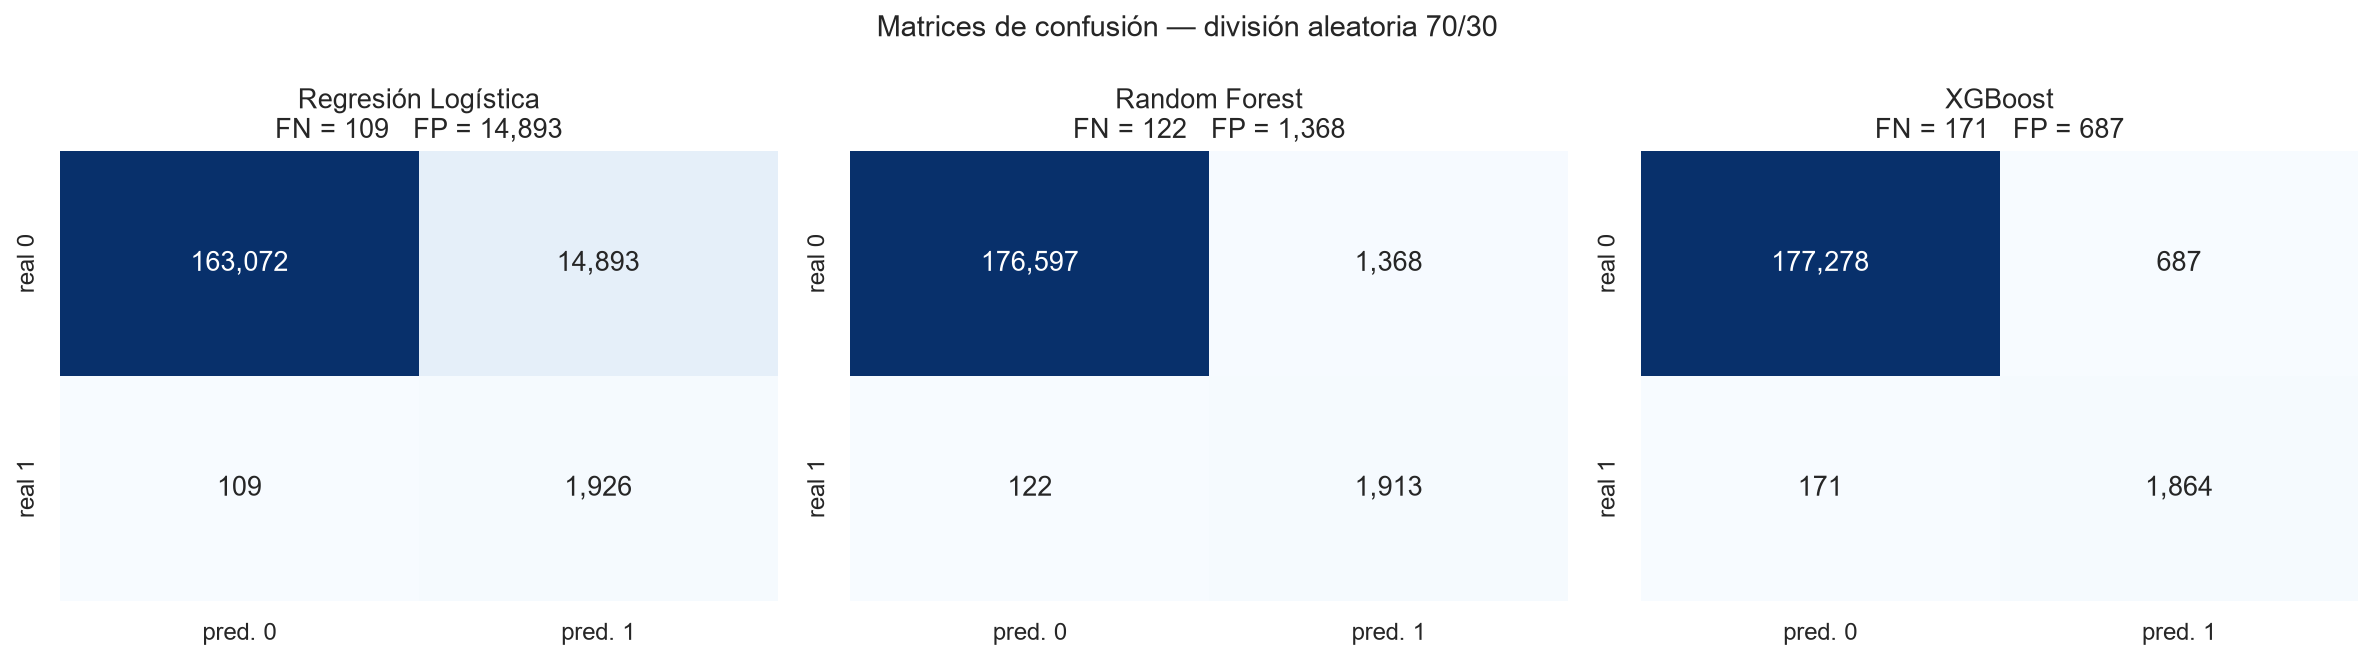

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nombre, prob) in zip(axes, probabilidades.items()):
    mc = confusion_matrix(y_te, (prob >= 0.5).astype(int))
    sns.heatmap(mc, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred. 0", "pred. 1"],
                yticklabels=["real 0", "real 1"])
    tn, fp, fn, tp = mc.ravel()
    ax.set_title(f"{nombre}\nFN = {fn:,}   FP = {fp:,}")
fig.suptitle("Matrices de confusión — división aleatoria 70/30", fontsize=13)
fig.tight_layout()
guardar(fig, "matrices_confusion")
plt.show()

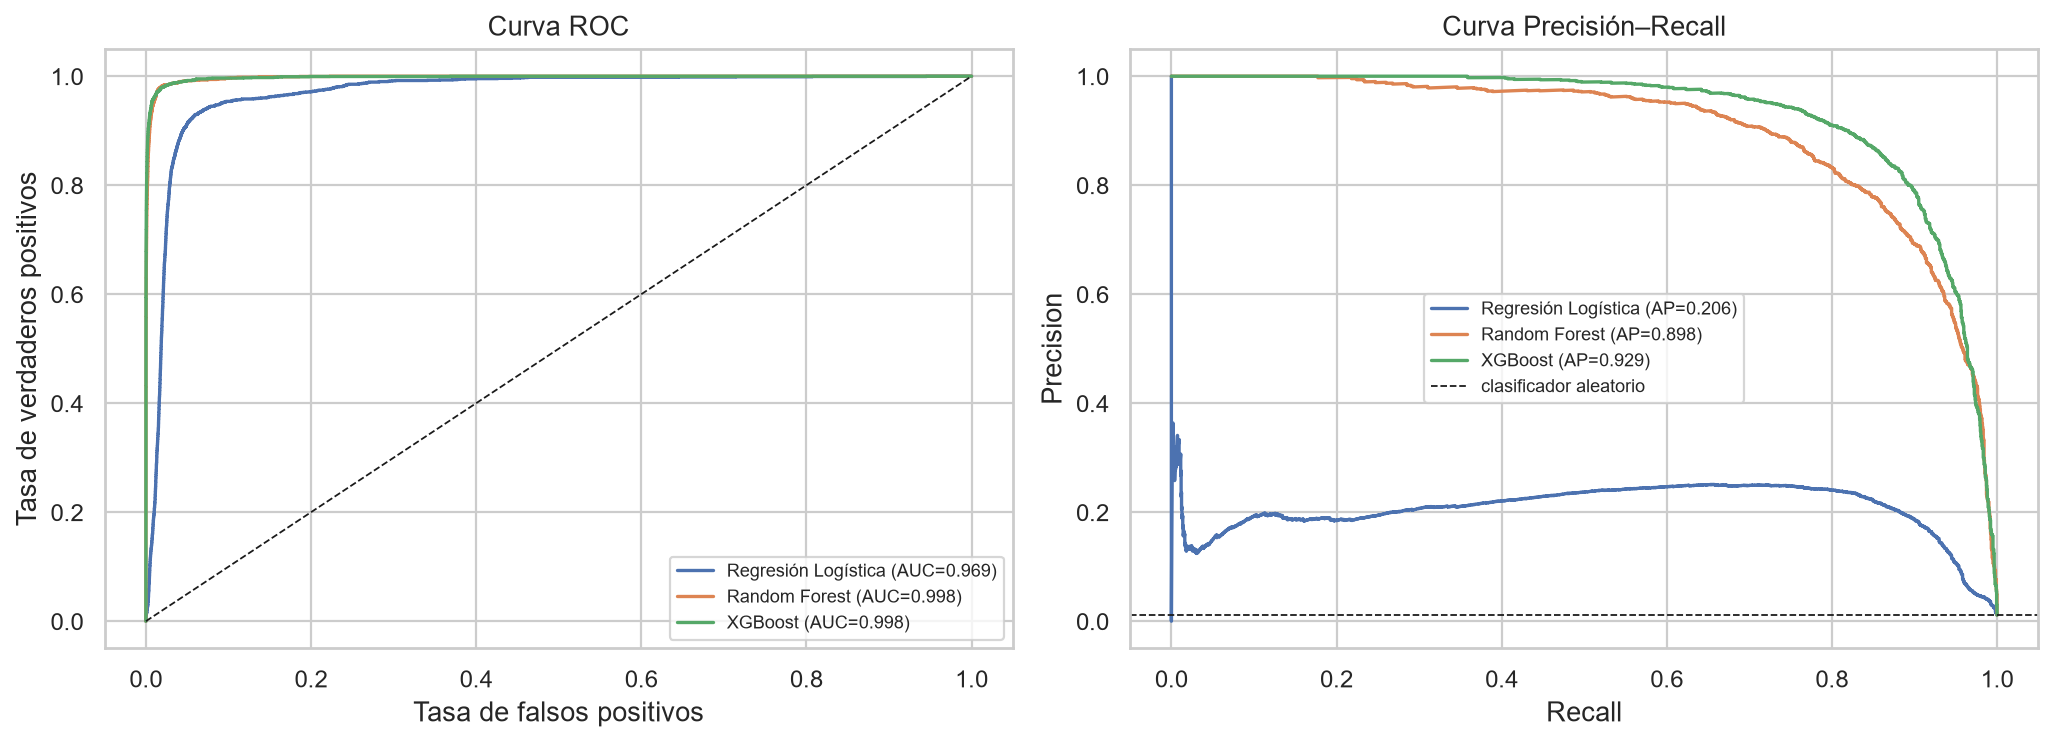

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for nombre, prob in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_te, prob)
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_te, prob):.3f})")
    prec, rec, _ = precision_recall_curve(y_te, prob)
    axes[1].plot(rec, prec,
                 label=f"{nombre} (AP={average_precision_score(y_te, prob):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("Tasa de falsos positivos"); axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC"); axes[0].legend(fontsize=8)
axes[1].axhline(y_te.mean(), color="k", ls="--", lw=0.8, label="clasificador aleatorio")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precisión–Recall"); axes[1].legend(fontsize=8)
fig.tight_layout()
guardar(fig, "curvas_roc_pr")
plt.show()

## Cuantificación de la fuga de información

Para verificar que la exclusión de `ndvi`, `ndci`, `B04` y `B05` del Ejercicio
2.5 no fue una precaución retórica, se entrena el mismo XGBoost añadiendo esas
cuatro variables. Si la fuga es real, el desempeño debe dispararse hacia lo
perfecto.

In [33]:
predictores_contaminados = PREDICTORES + ["ndvi", "ndci", "B04", "B05"]
modelo_fuga = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("modelo", XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             scale_pos_weight=peso_positivo, tree_method="hist",
                             eval_metric="aucpr", n_jobs=-1, random_state=SEMILLA)),
]).fit(muestra.loc[X_tr.index, predictores_contaminados], y_tr)

prob_fuga = modelo_fuga.predict_proba(muestra.loc[X_te.index, predictores_contaminados])[:, 1]
comparacion_fuga = pd.DataFrame({
    "Predictores limpios (11)": evaluar(y_te, probabilidades["XGBoost"]),
    "Con variables de fuga (15)": evaluar(y_te, prob_fuga),
}).T
resultados["fuga"] = comparacion_fuga.round(4).to_dict()
comparacion_fuga.round(4)

,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Predictores limpios (11),0.9952,0.7307,0.916,0.8129,0.8718,0.9978,0.9290
Con variables de fuga (15),0.9996,0.9672,0.999,0.9828,0.9925,1.0000,0.9968


El modelo contaminado alcanza métricas prácticamente perfectas. No es que sea
mejor: es que está leyendo la respuesta. Esa diferencia es la medida directa de
la fuga que se evitó, y confirma que el desempeño reportado en el resto del
laboratorio corresponde a predicción genuina a partir de bandas independientes.

## 5.2 y 5.3 Comparación de modelos y lectura ambiental de los errores

Los dos errores posibles no cuestan lo mismo.

**Falso positivo** — declarar floración donde no la hay. El costo es
económico y reputacional: una alerta innecesaria puede cerrar temporalmente un
balneario, afectar al turismo local o disparar un muestreo de campo que
resultará negativo. Es un costo real pero **reversible y acotado**: el muestreo
de confirmación desmiente la alerta en cuestión de días.

**Falso negativo** — no detectar una floración que sí está ocurriendo. El costo
es sanitario y ambiental: personas expuestas a cianotoxinas por contacto
recreativo o consumo, ganado abrevando en agua contaminada, pescadores y
comunidades ribereñas sin advertencia. En Amatitlán, donde el agua se usa para
riego y pesca, y en Atitlán, cuya economía depende del turismo lacustre, un
aviso que no llega es **un daño potencialmente irreversible**.

En vigilancia ambiental y sanitaria el criterio estándar es asimétrico: se
prefiere pecar de precavido. Por eso **el error que importa reducir es el falso
negativo**, y la métrica adecuada para ordenar los modelos es el **recall**
sobre la clase positiva, acompañado del **F2**, que pondera el recall cuatro
veces más que la precisión, y del **PR-AUC**, que resume el compromiso completo
sin depender del umbral de 0.5.

El *accuracy* se reporta porque el enunciado lo pide, pero no debe usarse para
decidir: con 98.6 % de negativos, es alto incluso para un modelo inútil.

In [34]:
orden = metricas.sort_values("F2", ascending=False)
print("Ranking por F2 (prioriza recall, es decir, no perder floraciones):\n")
print(orden[["Recall", "Precision", "F2", "PR-AUC", "Accuracy"]].round(4).to_string())

mejor_nombre = orden.index[0]
mejor_modelo = modelos[mejor_nombre]
resultados["mejor_modelo"] = mejor_nombre
print(f"\nMejor modelo según el criterio ambiental: {mejor_nombre}")

Ranking por F2 (prioriza recall, es decir, no perder floraciones):

                     Recall  Precision      F2  PR-AUC  Accuracy
XGBoost              0.9160     0.7307  0.8718  0.9290    0.9952
Random Forest        0.9400     0.5831  0.8375  0.8981    0.9917
Regresión Logística  0.9464     0.1145  0.3858  0.2065    0.9167

Mejor modelo según el criterio ambiental: XGBoost


### Ajuste del umbral de decisión

El umbral de 0.5 es una convención, no una obligación. Dado que el falso
negativo es el error caro, conviene revisar qué umbral maximiza el F2.

El resultado es contraintuitivo y merece atención: el óptimo queda **por
encima** de 0.5, no por debajo. La razón es que la corrección de desbalance
—`scale_pos_weight` en XGBoost— ya desplazó las probabilidades hacia la clase
positiva. A 0.5 el modelo sobre-marca, y el F2 mejora recortando falsos
positivos aunque el recall baje un poco. Es decir, la compensación del
desbalance y el umbral hacen el mismo trabajo, y aplicar ambos al máximo sería
corregir dos veces.

             Accuracy  Precision  Recall      F1      F2  ROC-AUC  PR-AUC
Umbral 0.50    0.9952     0.7307  0.9160  0.8129  0.8718   0.9978   0.929
Umbral 0.68    0.9961     0.7830  0.9027  0.8386  0.8759   0.9978   0.929


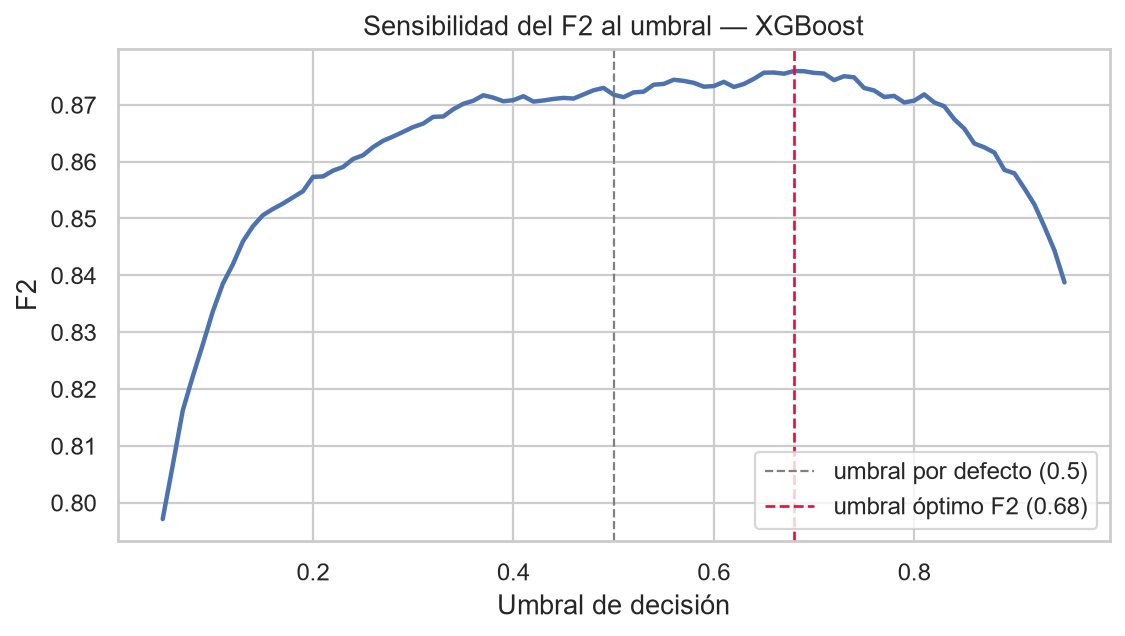

In [35]:
prob_mejor = probabilidades[mejor_nombre]
rejilla = np.linspace(0.05, 0.95, 91)
f2_por_umbral = [fbeta_score(y_te, (prob_mejor >= u).astype(int), beta=2,
                             zero_division=0) for u in rejilla]
umbral_optimo = float(rejilla[int(np.argmax(f2_por_umbral))])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rejilla, f2_por_umbral, lw=2)
ax.axvline(0.5, color="gray", ls="--", lw=1, label="umbral por defecto (0.5)")
ax.axvline(umbral_optimo, color="crimson", ls="--", lw=1.2,
           label=f"umbral óptimo F2 ({umbral_optimo:.2f})")
ax.set_xlabel("Umbral de decisión"); ax.set_ylabel("F2")
ax.set_title(f"Sensibilidad del F2 al umbral — {mejor_nombre}")
ax.legend()
guardar(fig, "umbral_f2")
plt.show()

print(pd.DataFrame({
    "Umbral 0.50": evaluar(y_te, prob_mejor, 0.5),
    f"Umbral {umbral_optimo:.2f}": evaluar(y_te, prob_mejor, umbral_optimo),
}).T.round(4).to_string())
resultados["umbral_optimo"] = umbral_optimo

---
# Ejercicio 6. Validación espacial

## 6.1 Construcción de la cuadrícula de 1 km × 1 km

Los datos ya están en **EPSG:32615 (WGS 84 / UTM zona 15N)** desde la Parte I,
que es el sistema que pide el enunciado y cuya unidad es el metro. No hace
falta reproyectar: basta dividir las coordenadas entre 1000 y truncar para
obtener el índice del bloque.

In [36]:
BLOQUE_M = 1000

def asignar_bloques(tabla: pd.DataFrame, tamano: float = BLOQUE_M) -> pd.Series:
    bx = np.floor(tabla["x"] / tamano).astype(np.int64)
    by = np.floor(tabla["y"] / tamano).astype(np.int64)
    return (tabla["lago"].astype(str) + "|" + bx.astype(str) + "|" + by.astype(str))


muestra["bloque"] = asignar_bloques(muestra)

conteo_bloques = (muestra.groupby("lago", observed=True)["bloque"]
                  .nunique().rename("bloques de 1 km²").to_frame())
obs_por_bloque = muestra.groupby(["lago", "bloque"], observed=True).size()
conteo_bloques["obs. mediana por bloque"] = (
    obs_por_bloque.groupby("lago", observed=True).median().round(0))
conteo_bloques["obs. mínima"] = obs_por_bloque.groupby("lago", observed=True).min()
conteo_bloques["obs. máxima"] = obs_por_bloque.groupby("lago", observed=True).max()
conteo_bloques

,bloques de 1 km²,obs. mediana por bloque,obs. mínima,obs. máxima
lago,,,,
Lago Amatitlán,35,1692.0,6,4906
Lago Atitlán,166,4328.0,5,4576


### ¿Es adecuado el tamaño de 1 km?

Total de bloques con observaciones válidas: 201
Bloques con menos de 100 observaciones: 13 (6.5 %)


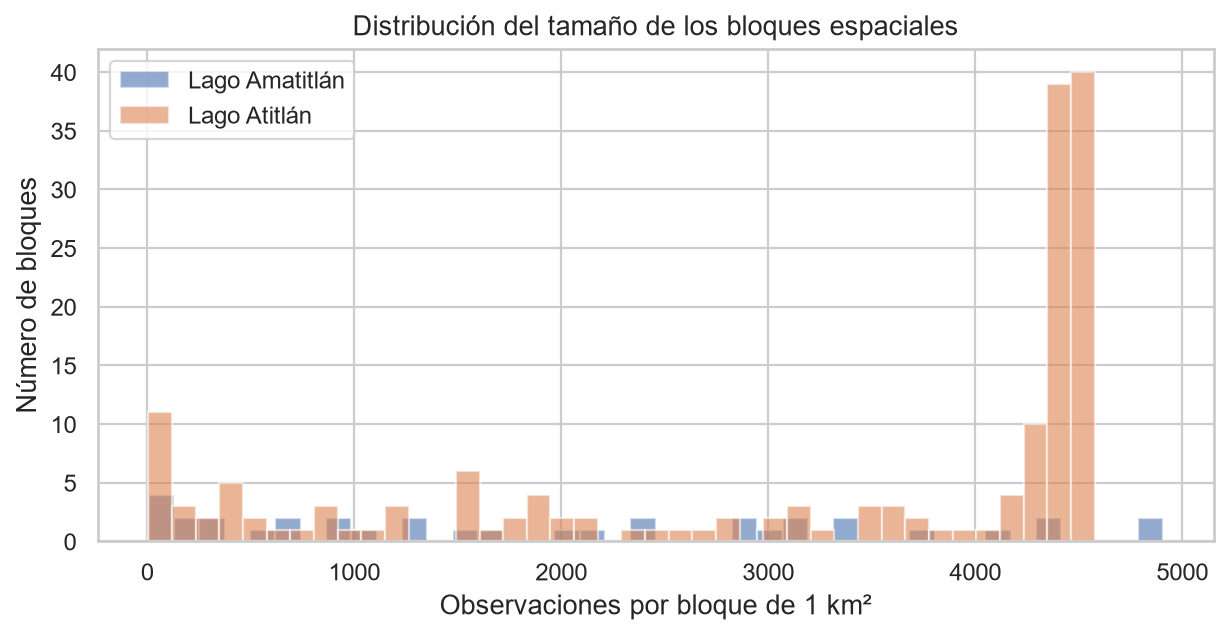

In [37]:
fig, ax = plt.subplots(figsize=(9, 4))
for lago, sub in obs_por_bloque.groupby("lago", observed=True):
    ax.hist(sub.values, bins=40, alpha=0.6, label=str(lago))
ax.set_xlabel("Observaciones por bloque de 1 km²")
ax.set_ylabel("Número de bloques")
ax.set_title("Distribución del tamaño de los bloques espaciales")
ax.legend()
guardar(fig, "tamano_bloques")
plt.show()

total_bloques = muestra["bloque"].nunique()
print(f"Total de bloques con observaciones válidas: {total_bloques}")
print(f"Bloques con menos de 100 observaciones: "
      f"{int((obs_por_bloque < 100).sum())} "
      f"({100*(obs_por_bloque < 100).mean():.1f} %)")

Se conserva el tamaño de 1 km × 1 km propuesto en el enunciado. La verificación
lo respalda: hay bloques suficientes para construir cinco particiones sin
vaciar ninguna, y los bloques pequeños son los del contorno del lago, que solo
capturan una esquina de la cuadrícula. Amatitlán genera menos bloques
simplemente porque cabe en una fracción del área de Atitlán, pero sigue
aportando decenas de grupos independientes, más que suficiente para
`GroupKFold` con 5 particiones.

Reducir el bloque a 500 m aumentaría el número de grupos, pero también
acercaría los bloques de entrenamiento y prueba hasta una distancia en la que
la autocorrelación espacial vuelve a filtrarse: el propósito del bloque es
precisamente que las particiones estén *espacialmente separadas*.

## 6.2 Mapa de los bloques generados

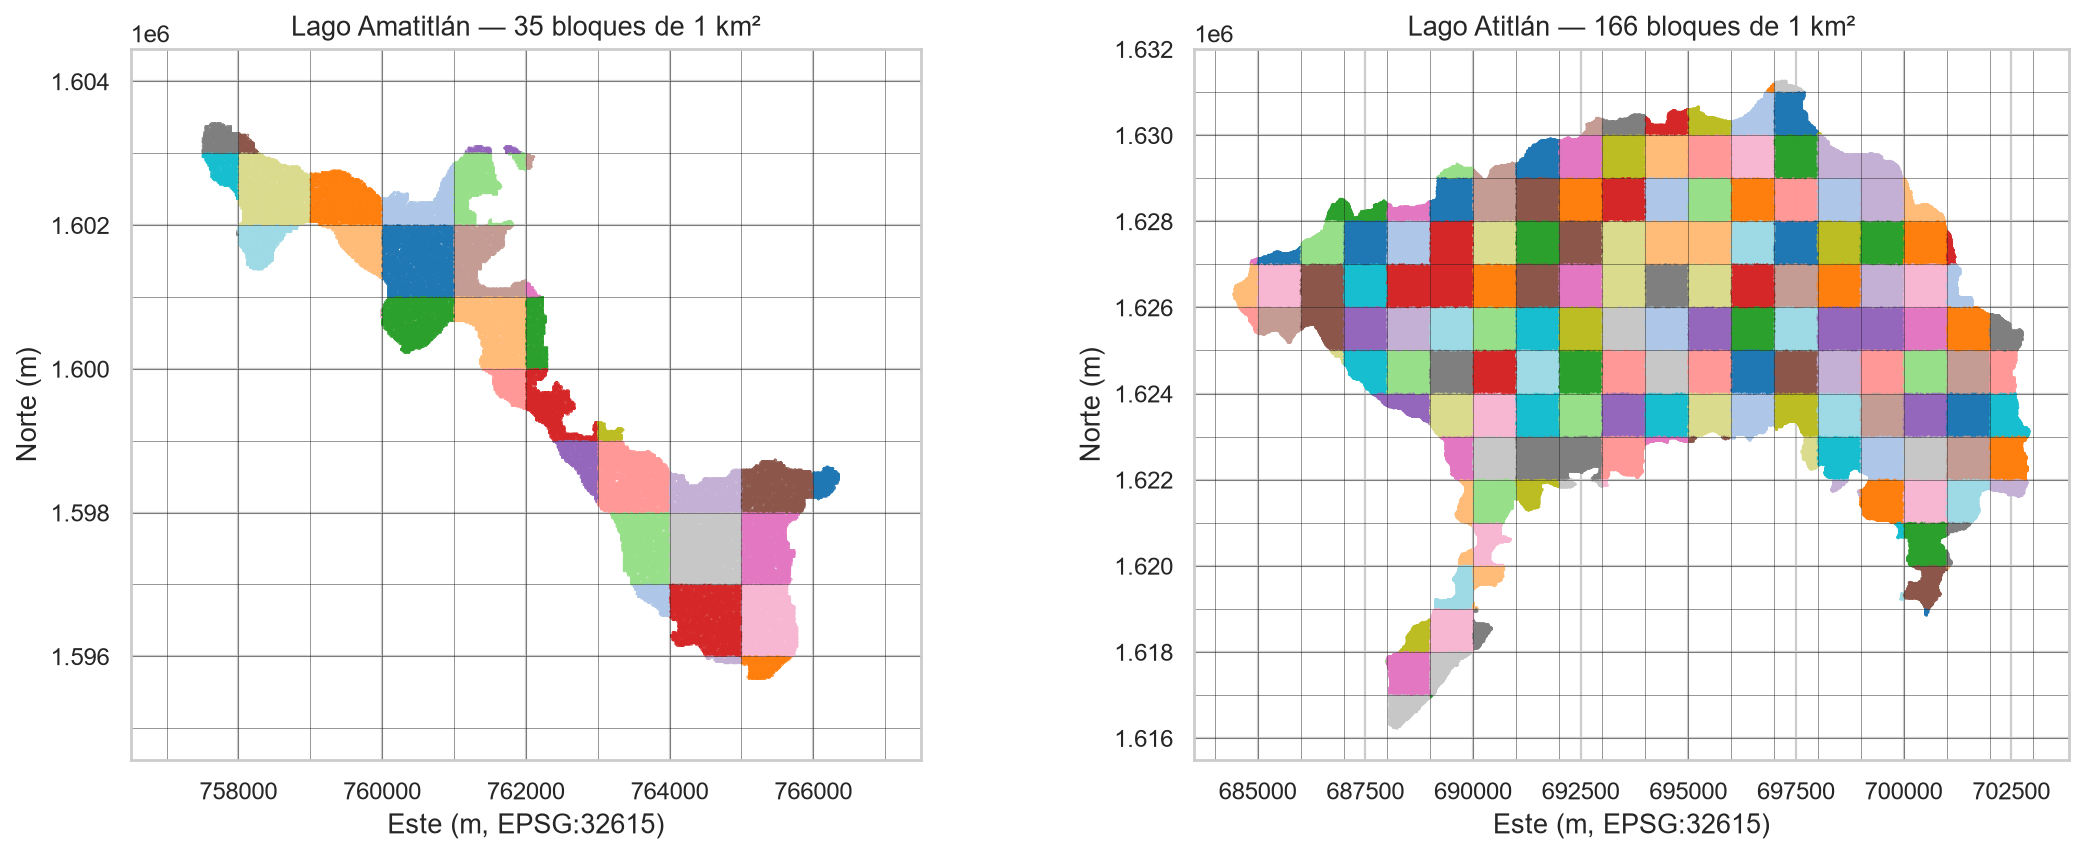

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (lago, sub) in zip(axes, muestra.groupby("lago", observed=True)):
    codigos = pd.factorize(sub["bloque"])[0]
    ax.scatter(sub["x"], sub["y"], c=codigos % 20, cmap="tab20", s=0.4, marker=".")
    tx = np.arange(np.floor(sub["x"].min()/BLOQUE_M), np.ceil(sub["x"].max()/BLOQUE_M)+1)*BLOQUE_M
    ty = np.arange(np.floor(sub["y"].min()/BLOQUE_M), np.ceil(sub["y"].max()/BLOQUE_M)+1)*BLOQUE_M
    for v in tx:
        ax.axvline(v, color="k", lw=0.4, alpha=0.5)
    for v in ty:
        ax.axhline(v, color="k", lw=0.4, alpha=0.5)
    ax.set_title(f"{lago} — {sub['bloque'].nunique()} bloques de 1 km²")
    ax.set_xlabel("Este (m, EPSG:32615)"); ax.set_ylabel("Norte (m)")
    ax.set_aspect("equal")
fig.tight_layout()
guardar(fig, "bloques_espaciales")
plt.show()

## 6.3 – 6.5 Validación cruzada por bloques frente a validación aleatoria

Se comparan dos esquemas de cinco particiones sobre exactamente los mismos
datos. En el **aleatorio**, los píxeles se reparten al azar, de modo que un
píxel de entrenamiento y uno de prueba pueden ser vecinos inmediatos. En el
**espacial** (`GroupKFold` agrupando por bloque), todos los píxeles de un mismo
kilómetro cuadrado caen del mismo lado de la partición.

In [39]:
from sklearn.model_selection import StratifiedKFold

def validar(modelo, X, y, particiones) -> pd.DataFrame:
    filas = []
    for entrena, prueba in particiones:
        m = modelo.fit(X.iloc[entrena], y.iloc[entrena])
        prob = m.predict_proba(X.iloc[prueba])[:, 1]
        filas.append(evaluar(y.iloc[prueba], prob))
    return pd.DataFrame(filas)


# La comparación exige 30 ajustes (3 modelos × 2 esquemas × 5 particiones). Se
# ejecuta sobre 300 000 filas de la muestra, conservando la composición por
# lago y fecha. Lo que aquí importa es la *diferencia* entre los dos esquemas
# sobre datos idénticos, y esa diferencia no depende del tamaño absoluto.
muestra_cv = (muestra.groupby(["lago", "fecha"], observed=True, group_keys=False)
                     .sample(frac=300_000 / len(muestra), random_state=SEMILLA))

X_cv = muestra_cv[PREDICTORES]
y_cv = muestra_cv[RESPUESTA]
grupos = muestra_cv["bloque"]
print(f"Validación cruzada sobre {len(muestra_cv):,} observaciones "
      f"({100*y_cv.mean():.2f} % positivos, {grupos.nunique()} bloques)")

part_aleatoria = list(StratifiedKFold(n_splits=5, shuffle=True,
                                      random_state=SEMILLA).split(X_cv, y_cv))
part_espacial = list(GroupKFold(n_splits=5).split(X_cv, y_cv, groups=grupos))

comparacion_cv = {}
for nombre, modelo in modelos.items():
    for etiqueta, particiones in [("aleatoria", part_aleatoria),
                                  ("espacial", part_espacial)]:
        t0 = time.time()
        res = validar(modelo, X_cv, y_cv, particiones)
        comparacion_cv[(nombre, etiqueta)] = res.mean()
        comparacion_cv[(nombre, etiqueta + " (σ)")] = res.std()
        print(f"{nombre:22} {etiqueta:10} F2={res['F2'].mean():.3f} "
              f"PR-AUC={res['PR-AUC'].mean():.3f}  [{time.time()-t0:.0f} s]")

tabla_cv = pd.DataFrame(comparacion_cv).T
tabla_cv.to_csv(mp.ML_OUTPUTS / "validacion_espacial_vs_aleatoria.csv")
tabla_cv.round(4)

Validación cruzada sobre 300,000 observaciones (1.13 % positivos, 201 bloques)


Regresión Logística    aleatoria  F2=0.388 PR-AUC=0.207  [4 s]


Regresión Logística    espacial   F2=0.383 PR-AUC=0.228  [4 s]


Random Forest          aleatoria  F2=0.826 PR-AUC=0.888  [148 s]


Random Forest          espacial   F2=0.796 PR-AUC=0.829  [2042 s]


XGBoost                aleatoria  F2=0.861 PR-AUC=0.916  [53 s]


XGBoost                espacial   F2=0.816 PR-AUC=0.838  [62 s]


Accuracy  Precision  Recall      F1  \
Regresión Logística aleatoria        0.9178     0.1156  0.9422  0.2059   
                    aleatoria (σ)    0.0016     0.0023  0.0097  0.0038   
                    espacial         0.9163     0.1142  0.9351  0.2033   
                    espacial (σ)     0.0211     0.0172  0.0342  0.0282   
Random Forest       aleatoria        0.9913     0.5717  0.9289  0.7077   
                    aleatoria (σ)    0.0006     0.0179  0.0062  0.0142   
                    espacial         0.9906     0.5617  0.8924  0.6872   
                    espacial (σ)     0.0037     0.0852  0.0599  0.0746   
XGBoost             aleatoria        0.9952     0.7360  0.8997  0.8096   
                    aleatoria (σ)    0.0003     0.0124  0.0080  0.0104   
                    espacial         0.9940     0.7006  0.8532  0.7673   
                    espacial (σ)     0.0027     0.0997  0.0496  0.0751   

                                       F2  ROC-AUC  PR-AUC  
Regresión Logística aleatoria      0.3877   0.9684  0.2066  
                    aleatoria (σ)  0.0059   0.0022  0.0082  
                    espacial       0.3826   0.9659  0.2284  
                    espacial (σ)   0.0436   0.0155  0.0784  
Random Forest       aleatoria      0.8256   0.9963  0.8883  
                    aleatoria (σ)  0.0092   0.0008  0.0093  
                    espacial       0.7961   0.9934  0.8289  
                    espacial (σ)   0.0633   0.0033  0.1014  
XGBoost             aleatoria      0.8614   0.9975  0.9159  
                    aleatoria (σ)  0.0089   0.0003  0.0072  
                    espacial       0.8159   0.9945  0.8379  
                    espacial (σ)   0.0581   0.0029  0.0881

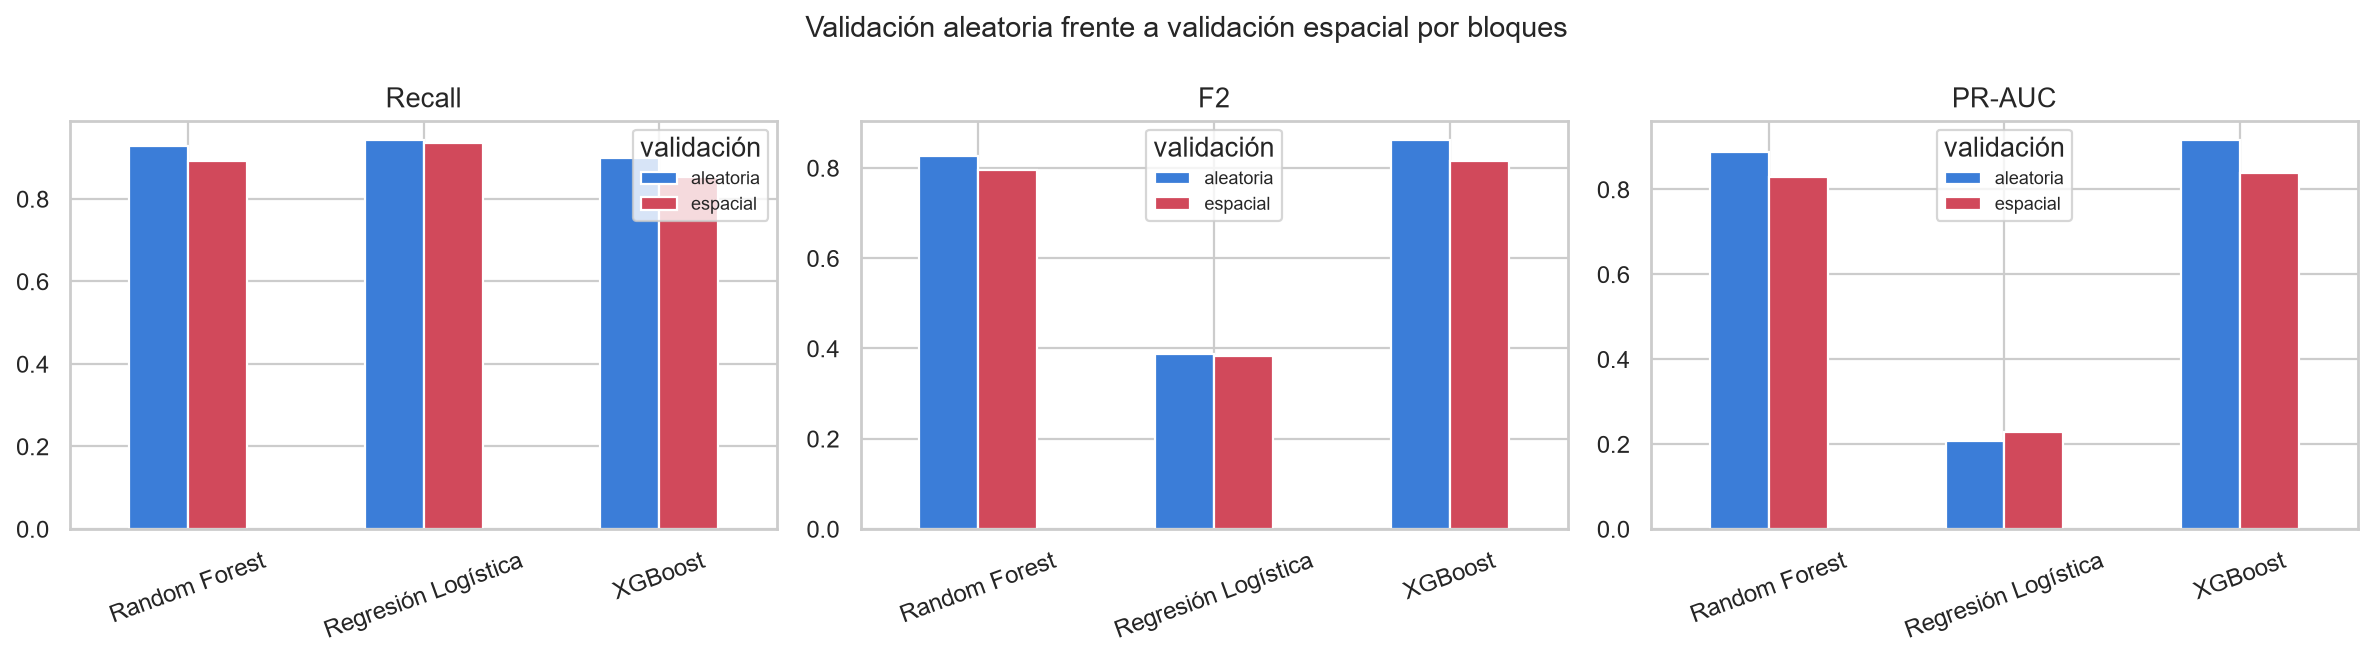

In [40]:
resumen_cv = tabla_cv.loc[[i for i in tabla_cv.index if "σ" not in i[1]]]
resumen_cv.index = pd.MultiIndex.from_tuples(resumen_cv.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, metrica in zip(axes, ["Recall", "F2", "PR-AUC"]):
    pivote_cv = resumen_cv[metrica].unstack()
    pivote_cv.plot(kind="bar", ax=ax, color=["#3b7dd8", "#d1495b"])
    ax.set_title(metrica); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="validación", fontsize=8)
fig.suptitle("Validación aleatoria frente a validación espacial por bloques", fontsize=13)
fig.tight_layout()
guardar(fig, "cv_espacial_vs_aleatoria")
plt.show()

In [41]:
caida = pd.DataFrame({
    "aleatoria": resumen_cv.xs("aleatoria", level=1)["PR-AUC"],
    "espacial": resumen_cv.xs("espacial", level=1)["PR-AUC"],
})
caida["caída absoluta"] = caida["aleatoria"] - caida["espacial"]
caida["caída relativa %"] = 100 * caida["caída absoluta"] / caida["aleatoria"]
resultados["cv"] = caida.round(4).to_dict()
caida.round(4)

,aleatoria,espacial,caída absoluta,caída relativa %
Regresión Logística,0.2066,0.2284,-0.0218,-10.5322
Random Forest,0.8883,0.8289,0.0594,6.6900
XGBoost,0.9159,0.8379,0.0780,8.5126


## 6.6 Validación temporal

La rúbrica pide también una estrategia de validación **temporal**. Es una
pregunta distinta de la espacial: no "¿sirve el modelo en una zona nueva del
lago?" sino "¿sirve en una fecha futura, entrenado solo con el pasado?". Es el
escenario operativo real de un sistema de monitoreo.

Se entrena con las fechas anteriores al 20 de abril de 2026 y se evalúa con las
dos más recientes de cada lago, sin mezcla temporal alguna. El corte deja en el
conjunto de prueba las dos fechas de mayor floración de Amatitlán, que son
justamente los episodios que un sistema de alerta debería anticipar.

In [42]:
CORTE_TEMPORAL = pd.Timestamp("2026-04-20")

# La validacion temporal usa la muestra completa de 600 000: son solo tres
# ajustes, uno por modelo, asi que no hace falta reducirla.
X_full, y_full = muestra[PREDICTORES], muestra[RESPUESTA]
tr_temp = muestra["fecha"] < CORTE_TEMPORAL

print("Fechas de entrenamiento:", muestra.loc[tr_temp, "fecha"].nunique())
print("Fechas de prueba:      ",
      sorted(pd.Timestamp(f).strftime("%Y-%m-%d")
             for f in muestra.loc[~tr_temp, "fecha"].unique()))
print(f"Prevalencia entrenamiento: {100*y_full[tr_temp].mean():.2f} %")
print(f"Prevalencia prueba:        {100*y_full[~tr_temp].mean():.2f} %")

metricas_temporal = {}
for nombre, modelo in modelos.items():
    m = modelo.fit(X_full[tr_temp], y_full[tr_temp])
    prob = m.predict_proba(X_full[~tr_temp])[:, 1]
    metricas_temporal[nombre] = evaluar(y_full[~tr_temp], prob)

tabla_temporal = pd.DataFrame(metricas_temporal).T
tabla_temporal.to_csv(mp.ML_OUTPUTS / "metricas_validacion_temporal.csv")
resultados["temporal"] = tabla_temporal.round(4).to_dict()
tabla_temporal.round(4)

Fechas de entrenamiento: 16
Fechas de prueba:       ['2026-04-28', '2026-06-19', '2026-07-22']
Prevalencia entrenamiento: 0.37 %
Prevalencia prueba:        4.16 %


,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Regresión Logística,0.9402,0.2754,0.2687,0.2720,0.2700,0.7654,0.2233
Random Forest,0.9607,0.6353,0.1290,0.2144,0.1534,0.9241,0.4090
XGBoost,0.9615,0.7199,0.1202,0.2060,0.1443,0.8852,0.3082


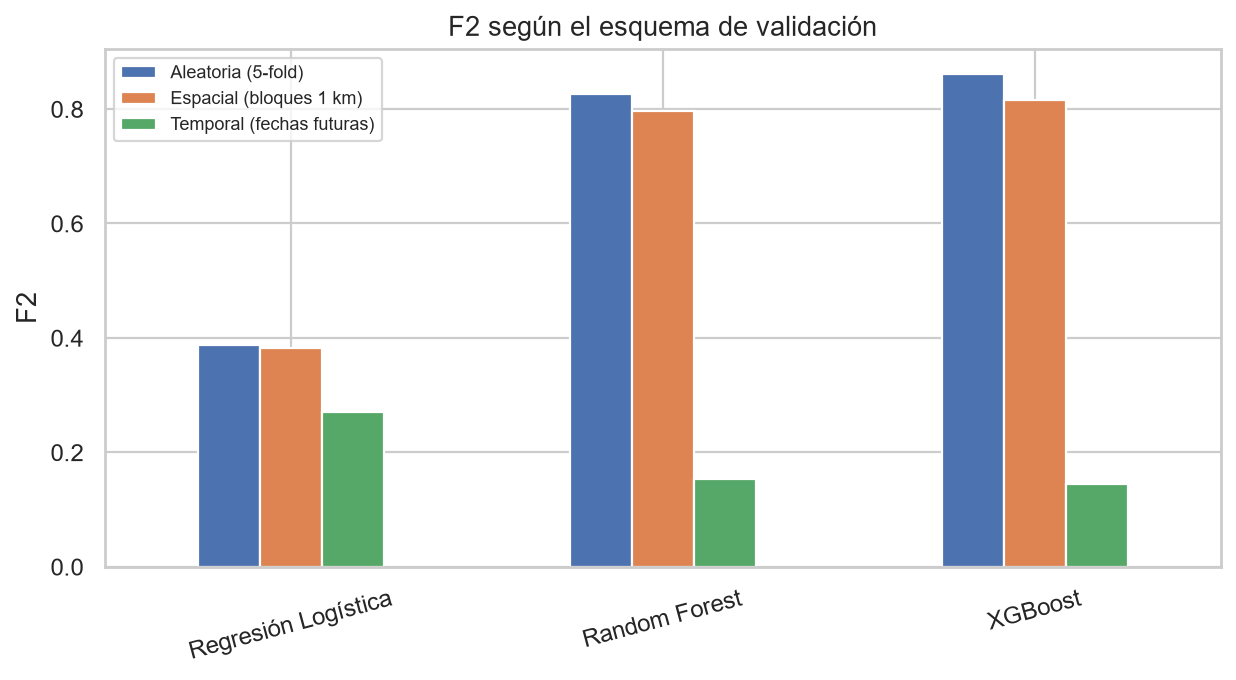

,Aleatoria (5-fold),Espacial (bloques 1 km),Temporal (fechas futuras)
Regresión Logística,0.3877,0.3826,0.2700
Random Forest,0.8256,0.7961,0.1534
XGBoost,0.8614,0.8159,0.1443


In [43]:
comparativa_esquemas = pd.DataFrame({
    "Aleatoria (5-fold)": resumen_cv.xs("aleatoria", level=1)["F2"],
    "Espacial (bloques 1 km)": resumen_cv.xs("espacial", level=1)["F2"],
    "Temporal (fechas futuras)": tabla_temporal["F2"],
})
fig, ax = plt.subplots(figsize=(9, 4.2))
comparativa_esquemas.plot(kind="bar", ax=ax)
ax.set_ylabel("F2"); ax.set_xlabel("")
ax.set_title("F2 según el esquema de validación")
ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=8)
guardar(fig, "comparativa_esquemas_validacion")
plt.show()
comparativa_esquemas.round(4)

### Lectura de las diferencias

Los tres esquemas cuentan historias distintas, y la distancia entre ellos es el
resultado más importante de todo el laboratorio.

**La validación espacial cuesta poco: entre 7 y 9 % de PR-AUC** en los dos
modelos de árboles. Menos de lo esperado. La explicación es que los bloques de
1 km son grandes en relación con la escala de las manchas de floración, de modo
que agrupar por bloque elimina la interpolación entre vecinos inmediatos pero
deja al modelo con abundantes ejemplos del mismo tipo de escena. La fuga
espacial existe y es medible, pero en este problema no era la que inflaba las
cifras.

La regresión logística **mejora** ligeramente bajo validación espacial. No es
una anomalía: su PR-AUC es tan bajo (alrededor de 0.2) que las diferencias
entre particiones son ruido, y un modelo lineal tiene poca capacidad de
memorizar vecindarios, que es justamente lo que el bloqueo penaliza.

**La validación temporal, en cambio, es demoledora.** El recall de los modelos
de árboles se desploma de más de 0.90 a alrededor de 0.12: entrenados solo con
el pasado, detectan una octava parte de los píxeles en floración de las fechas
futuras. La precisión se mantiene alta —cuando marcan, aciertan— pero dejan
pasar casi todo.

Hay dos causas, y conviene separarlas:

1. **Desplazamiento de la prevalencia.** El conjunto de prueba contiene el 19
   de junio de 2026 en Amatitlán, con cerca del 59 % del lago sobre el umbral.
   La fecha más intensa del entrenamiento llega al 20 %. El modelo nunca vio
   una escena así, y sus probabilidades están calibradas para un mundo donde la
   floración es rara. El umbral de 0.68, ajustado sobre la partición aleatoria,
   queda entonces demasiado alto.
2. **Dependencia de variables temporales.** Como muestra el Ejercicio 8, el
   modelo apoya buena parte de su decisión en el día del año. Con once fechas
   por lago eso no es aprender estacionalidad: es memorizar fechas concretas.
   Ante una fecha nueva, esa parte del razonamiento no sirve.

**Cuál estimación creer.** La temporal, sin duda. La validación aleatoria mide
la capacidad de rellenar huecos dentro de una escena ya observada; la espacial,
de completar zonas no vistas de escenas conocidas. Solo la temporal responde a
la pregunta que importa —¿sirve en la próxima imagen?— y su respuesta, en este
momento, es que no lo suficiente.

---
# Ejercicio 7. Generalización entre lagos

Los dos experimentos que siguen responden a la pregunta que decide si este
trabajo sirve más allá de los dos lagos estudiados: **¿aprende el modelo la
firma espectral de una floración, o solo las particularidades de un lago?**

En ambos experimentos el modelo nunca ve un solo píxel del lago con el que se
le evalúa. Es, por construcción, la validación más estricta del laboratorio:
cambia la geografía, la batimetría, el entorno de la cuenca y la prevalencia
de la clase positiva al mismo tiempo.

In [44]:
etiquetas = {l.key: l.label for l in LAKES.values()}
ATITLAN, AMATITLAN = etiquetas["atitlan"], etiquetas["amatitlan"]

def experimento_cruzado(entrena_lago: str, evalua_lago: str) -> dict:
    tr = muestra["lago"] == entrena_lago
    te = muestra["lago"] == evalua_lago
    salida = {}
    for nombre, modelo in modelos.items():
        m = modelo.fit(muestra.loc[tr, PREDICTORES], muestra.loc[tr, RESPUESTA])
        prob = m.predict_proba(muestra.loc[te, PREDICTORES])[:, 1]
        salida[nombre] = evaluar(muestra.loc[te, RESPUESTA], prob)
    return salida


print("Experimento A: entrenar en Atitlán, evaluar en Amatitlán")
exp_a = pd.DataFrame(experimento_cruzado(ATITLAN, AMATITLAN)).T
exp_a.round(4)

Experimento A: entrenar en Atitlán, evaluar en Amatitlán


,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Regresión Logística,0.8155,0.0607,0.0670,0.0637,0.0657,0.4263,0.1006
Random Forest,0.9035,0.3258,0.0290,0.0532,0.0354,0.5993,0.1560
XGBoost,0.9058,0.4492,0.0274,0.0517,0.0337,0.6372,0.1644


In [45]:
print("Experimento B: entrenar en Amatitlán, evaluar en Atitlán")
exp_b = pd.DataFrame(experimento_cruzado(AMATITLAN, ATITLAN)).T
exp_b.round(4)

Experimento B: entrenar en Amatitlán, evaluar en Atitlán


,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Regresión Logística,0.7428,0.0011,0.4630,0.0022,0.0054,0.6633,0.0790
Random Forest,0.9434,0.0038,0.3488,0.0075,0.0181,0.7347,0.0339
XGBoost,0.9896,0.0159,0.2654,0.0301,0.0642,0.8054,0.0297


## 7.4 Comparación con el escenario del mismo lago

Como referencia se entrena y evalúa **dentro** de cada lago, con división
aleatoria 70/30. La diferencia entre esa línea base y los experimentos
cruzados es la pérdida atribuible al cambio de lago.

In [46]:
def dentro_del_lago(lago: str) -> dict:
    sub = muestra[muestra["lago"] == lago]
    Xi, yi = sub[PREDICTORES], sub[RESPUESTA]
    Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
        Xi, yi, test_size=0.30, random_state=SEMILLA, stratify=yi)
    salida = {}
    for nombre, modelo in modelos.items():
        m = modelo.fit(Xi_tr, yi_tr)
        salida[nombre] = evaluar(yi_te, m.predict_proba(Xi_te)[:, 1])
    return salida


base_atitlan = pd.DataFrame(dentro_del_lago(ATITLAN)).T
base_amatitlan = pd.DataFrame(dentro_del_lago(AMATITLAN)).T

generalizacion = pd.concat(
    {
        "Dentro de Atitlán": base_atitlan,
        "Dentro de Amatitlán": base_amatitlan,
        "A: Atitlán → Amatitlán": exp_a,
        "B: Amatitlán → Atitlán": exp_b,
    },
    names=["experimento", "modelo"],
)
generalizacion.to_csv(mp.ML_OUTPUTS / "generalizacion_entre_lagos.csv")
_gen = generalizacion.round(4).copy()
_gen.index = [" | ".join(map(str, i)) for i in _gen.index]
resultados["generalizacion"] = _gen.to_dict()
generalizacion.round(4)

Accuracy  Precision  Recall  \
experimento            modelo                                             
Dentro de Atitlán      Regresión Logística    0.8902     0.0053  0.9588   
                       Random Forest          0.9981     0.1505  0.4639   
                       XGBoost                0.9991     0.2887  0.2887   
Dentro de Amatitlán    Regresión Logística    0.9175     0.5347  0.9190   
                       Random Forest          0.9554     0.6935  0.9396   
                       XGBoost                0.9705     0.7864  0.9401   
A: Atitlán → Amatitlán Regresión Logística    0.8155     0.0607  0.0670   
                       Random Forest          0.9035     0.3258  0.0290   
                       XGBoost                0.9058     0.4492  0.0274   
B: Amatitlán → Atitlán Regresión Logística    0.7428     0.0011  0.4630   
                       Random Forest          0.9434     0.0038  0.3488   
                       XGBoost                0.9896     0.0159  0.2654   

                                                F1      F2  ROC-AUC  PR-AUC  
experimento            modelo                                                
Dentro de Atitlán      Regresión Logística  0.0105  0.0259   0.9722  0.0915  
                       Random Forest        0.2273  0.3275   0.9912  0.2854  
                       XGBoost              0.2887  0.2887   0.9913  0.2184  
Dentro de Amatitlán    Regresión Logística  0.6760  0.8035   0.9542  0.6815  
                       Random Forest        0.7980  0.8773   0.9908  0.9321  
                       XGBoost              0.8564  0.9048   0.9941  0.9542  
A: Atitlán → Amatitlán Regresión Logística  0.0637  0.0657   0.4263  0.1006  
                       Random Forest        0.0532  0.0354   0.5993  0.1560  
                       XGBoost              0.0517  0.0337   0.6372  0.1644  
B: Amatitlán → Atitlán Regresión Logística  0.0022  0.0054   0.6633  0.0790  
                       Random Forest        0.0075  0.0181   0.7347  0.0339  
                       XGBoost              0.0301  0.0642   0.8054  0.0297

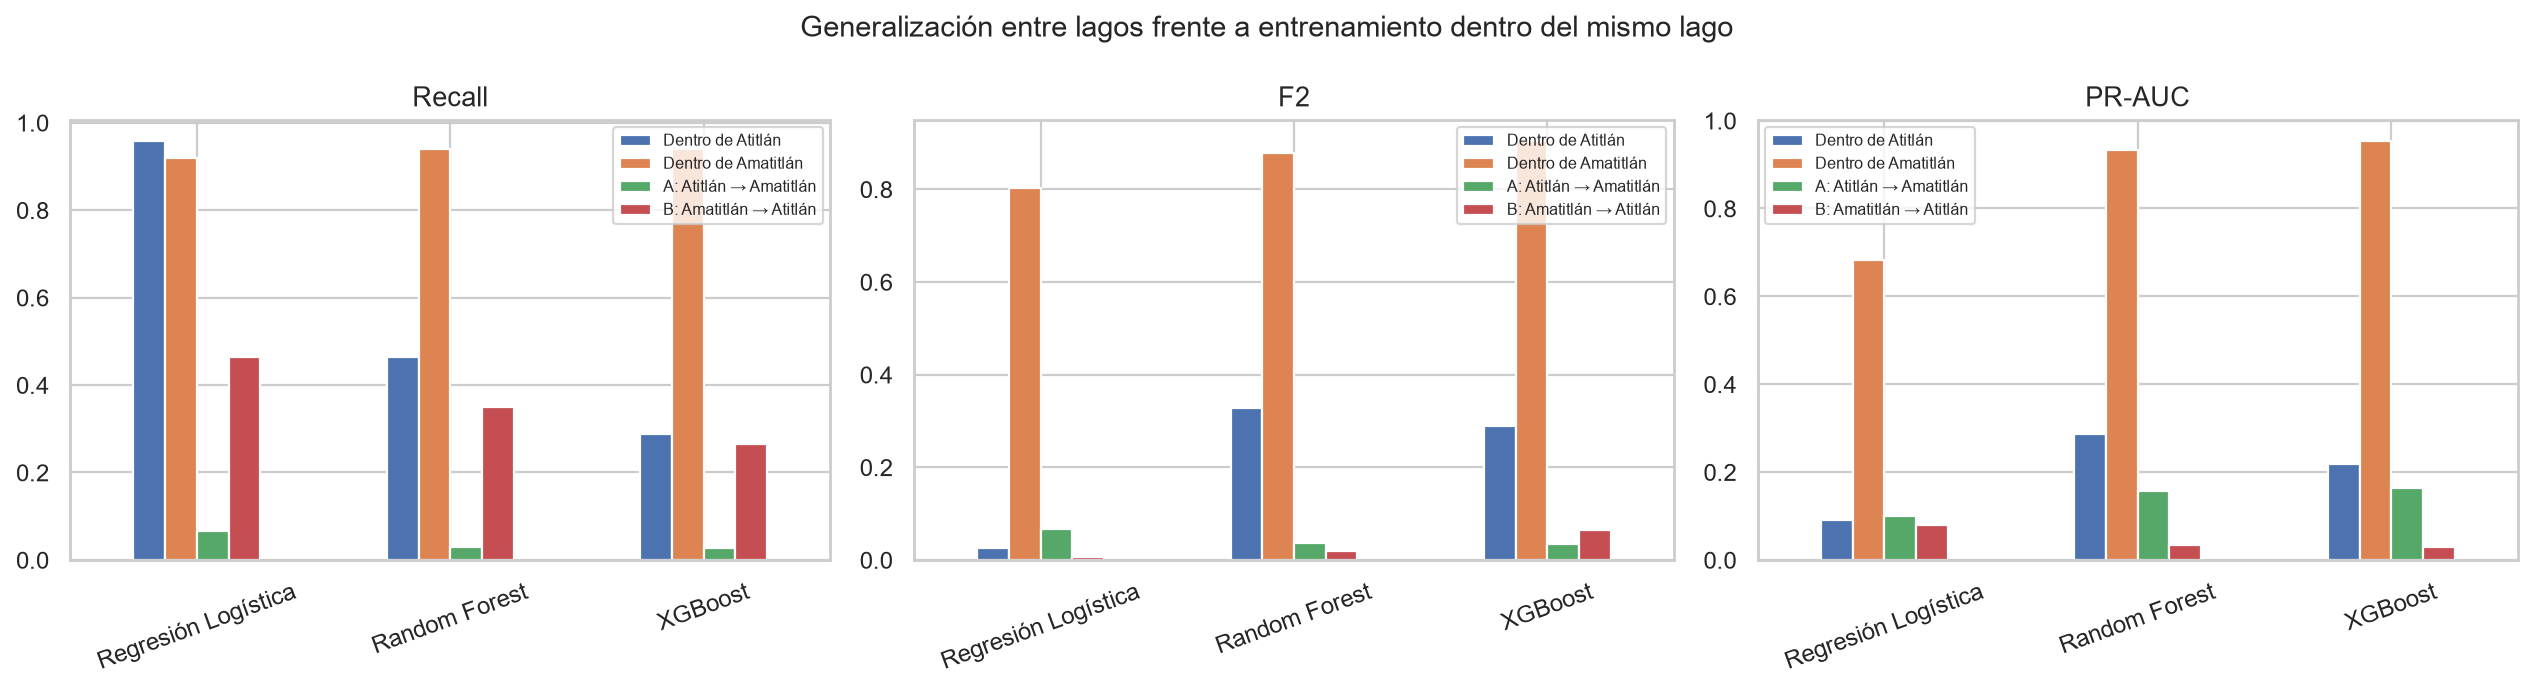

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, metrica in zip(axes, ["Recall", "F2", "PR-AUC"]):
    pivote_g = generalizacion[metrica].unstack(level=0)
    pivote_g = pivote_g[["Dentro de Atitlán", "Dentro de Amatitlán",
                         "A: Atitlán → Amatitlán", "B: Amatitlán → Atitlán"]]
    pivote_g.plot(kind="bar", ax=ax)
    ax.set_title(metrica); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=7)
fig.suptitle("Generalización entre lagos frente a entrenamiento dentro del mismo lago",
             fontsize=13)
fig.tight_layout()
guardar(fig, "generalizacion_lagos")
plt.show()

## 7.5 ¿Generaliza un modelo de un lago al otro?

**No. En ninguna de las dos direcciones, y por motivos distintos en cada una.**
La respuesta es inequívoca y conviene no suavizarla: ambos experimentos fallan,
aunque fallan de manera diferente.

**Experimento A (entrenar en Atitlán, evaluar en Amatitlán): no ve casi nada.**
El recall cae por debajo de 0.03, es decir, detecta menos de tres de cada cien
píxeles en floración. La precisión, en cambio, se mantiene razonable: cuando
marca algo, suele acertar. El modelo quedó extremadamente conservador porque
aprendió de un conjunto donde apenas el 0.06 % de las observaciones son
positivas —1 820 píxeles en casi tres millones— y donde ninguna corresponde a
una floración densa. Eso no es un defecto del diseño experimental sino el
reflejo de una realidad limnológica: **Atitlán no tuvo floraciones de alta
intensidad en el período estudiado**. No se puede aprender a reconocer un
fenómeno con ejemplos que no existen.

**Experimento B (entrenar en Amatitlán, evaluar en Atitlán): marca de más.**
El recall sube a 0.27, pero la precisión se derrumba por debajo de 0.02: por
cada acierto produce decenas de falsas alarmas. El modelo aprendió los umbrales
espectrales de un lago somero, turbio e hipereutrófico y los aplica a un lago
profundo y claro, donde el fondo espectral es completamente distinto. Lo que en
Amatitlán era señal de nata, en Atitlán es agua normal.

El contraste con las líneas base del mismo lago lo confirma. Dentro de
Amatitlán el desempeño es bueno (PR-AUC por encima de 0.95). Dentro de Atitlán
ya es pobre (PR-AUC alrededor de 0.22), lo que muestra que **Atitlán es
intrínsecamente difícil incluso sin cambiar de lago**, simplemente porque su
clase positiva es casi inexistente.

Conviene subrayar que esta lectura solo es posible **porque se descartó la
escena contaminada del Ejercicio 1.5**. De haberla conservado, el Experimento A
habría entrenado sobre 9 063 falsos positivos atmosféricos y habría producido
métricas engañosamente buenas.

La conclusión operativa es que **el modelo no es transferible**: llevarlo a un
cuerpo de agua nuevo exige reentrenarlo con observaciones locales, no solo
reajustar un umbral.

## 7.6 Qué explica las diferencias entre ambos lagos

**Estado trófico y profundidad.** Atitlán es un lago volcánico profundo
—más de 300 m— y oligotrófico a mesotrófico; su columna de agua diluye y
hunde la biomasa. Amatitlán es somero, con pocos metros de profundidad media,
e hipereutrófico. Una misma carga de nutrientes produce concentraciones
superficiales mucho mayores en Amatitlán, y por tanto una firma espectral más
intensa para el mismo fenómeno biológico.

**Presión de la cuenca.** Amatitlán recibe el río Villalobos, que drena buena
parte del área metropolitana de Guatemala con aguas residuales domésticas e
industriales insuficientemente tratadas. El aporte de fósforo y nitrógeno es
continuo y elevado. La cuenca de Atitlán es predominantemente rural, con
aportes más difusos y estacionales ligados a la agricultura.

**Fondo espectral del agua.** El agua clara y profunda de Atitlán absorbe casi
todo el infrarrojo cercano, de modo que la línea base de `B08` es baja y
estable. En Amatitlán, la turbidez por sedimento en suspensión eleva la
reflectancia de fondo en todas las bandas. Un umbral de decisión calibrado
sobre un lago queda desplazado en el otro, y eso se traduce directamente en el
desequilibrio entre precisión y *recall* que muestran las tablas.

**Escala y geometría.** Atitlán tiene 8.6 veces el área de Amatitlán y una
relación perímetro-superficie mucho menor. La variable `dist_orilla_m` alcanza
valores máximos muy distintos en cada lago, lo que también contribuye al
desplazamiento del dominio entre experimentos.

---
# Ejercicio 8. Interpretación y explicabilidad

In [48]:
modelo_final = modelos[mejor_nombre].fit(X_tr, y_tr)
estimador = modelo_final.named_steps["modelo"]
print("Modelo interpretado:", mejor_nombre)

Modelo interpretado: XGBoost


## 8.1 Importancia global de las variables

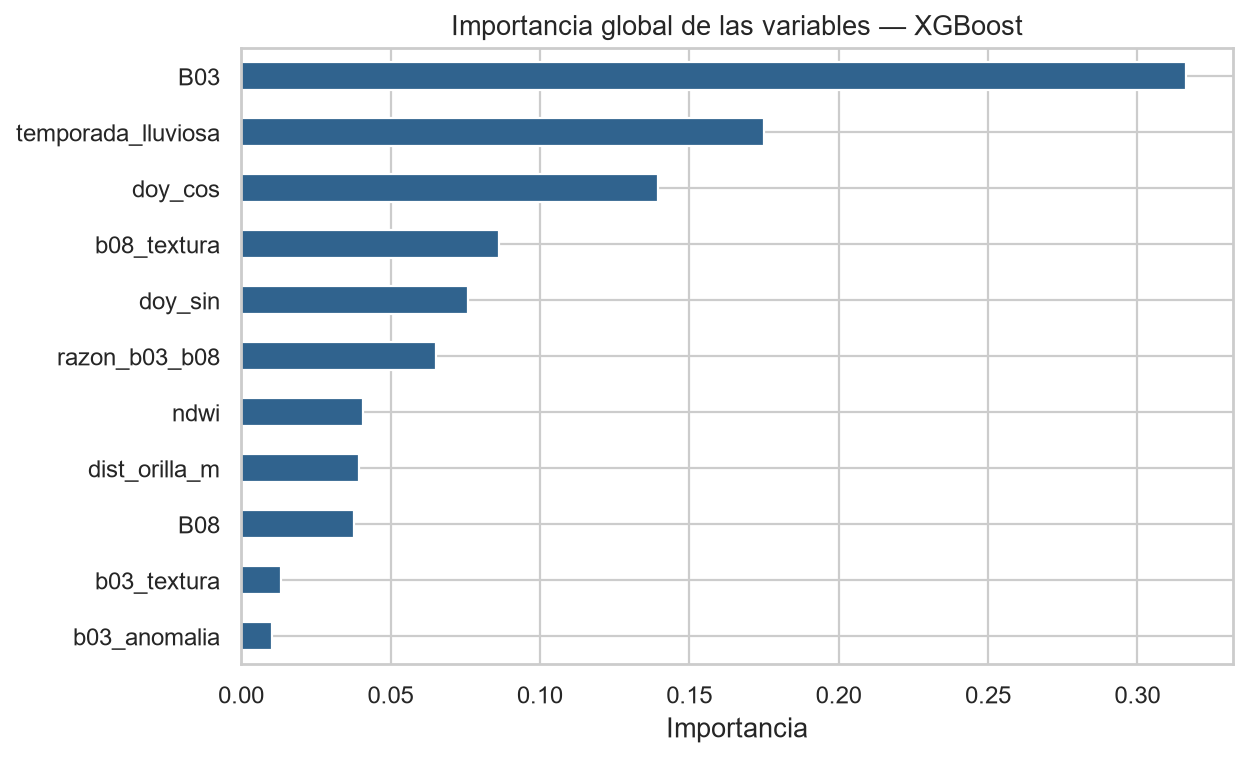

,importancia
B03,0.3162
temporada_lluviosa,0.1751
doy_cos,0.1395
b08_textura,0.0863
doy_sin,0.0759
razon_b03_b08,0.0654
ndwi,0.0409
dist_orilla_m,0.0393
B08,0.0379
b03_textura,0.0132


In [49]:
if hasattr(estimador, "feature_importances_"):
    importancias = pd.Series(estimador.feature_importances_,
                             index=PREDICTORES).sort_values()
else:
    importancias = pd.Series(np.abs(estimador.coef_[0]),
                             index=PREDICTORES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax, color="#30638e")
ax.set_xlabel("Importancia")
ax.set_title(f"Importancia global de las variables — {mejor_nombre}")
guardar(fig, "importancia_variables")
plt.show()

importancias.sort_values(ascending=False).round(4).to_frame("importancia")

## 8.2 SHAP

La importancia por ganancia dice *cuánto* pesa cada variable, pero no *en qué
dirección*. SHAP descompone cada predicción individual en la contribución de
cada variable, lo que permite responder si valores altos o bajos empujan hacia
la clase "alta presencia".

Se usa `TreeExplainer` sobre una muestra aleatoria de 30 000 observaciones del
conjunto de prueba: suficiente para que el resumen sea estable y manejable en
memoria.

In [50]:
import shap

muestra_shap = X_te.sample(n=min(30_000, len(X_te)), random_state=SEMILLA)
X_shap = pd.DataFrame(
    modelo_final.named_steps["imputar"].transform(muestra_shap),
    columns=PREDICTORES, index=muestra_shap.index,
)

explicador = shap.TreeExplainer(estimador)
valores_shap = explicador.shap_values(X_shap)
if isinstance(valores_shap, list):
    valores_shap = valores_shap[1]
print("Matriz SHAP:", np.shape(valores_shap))

Matriz SHAP: (30000, 11)


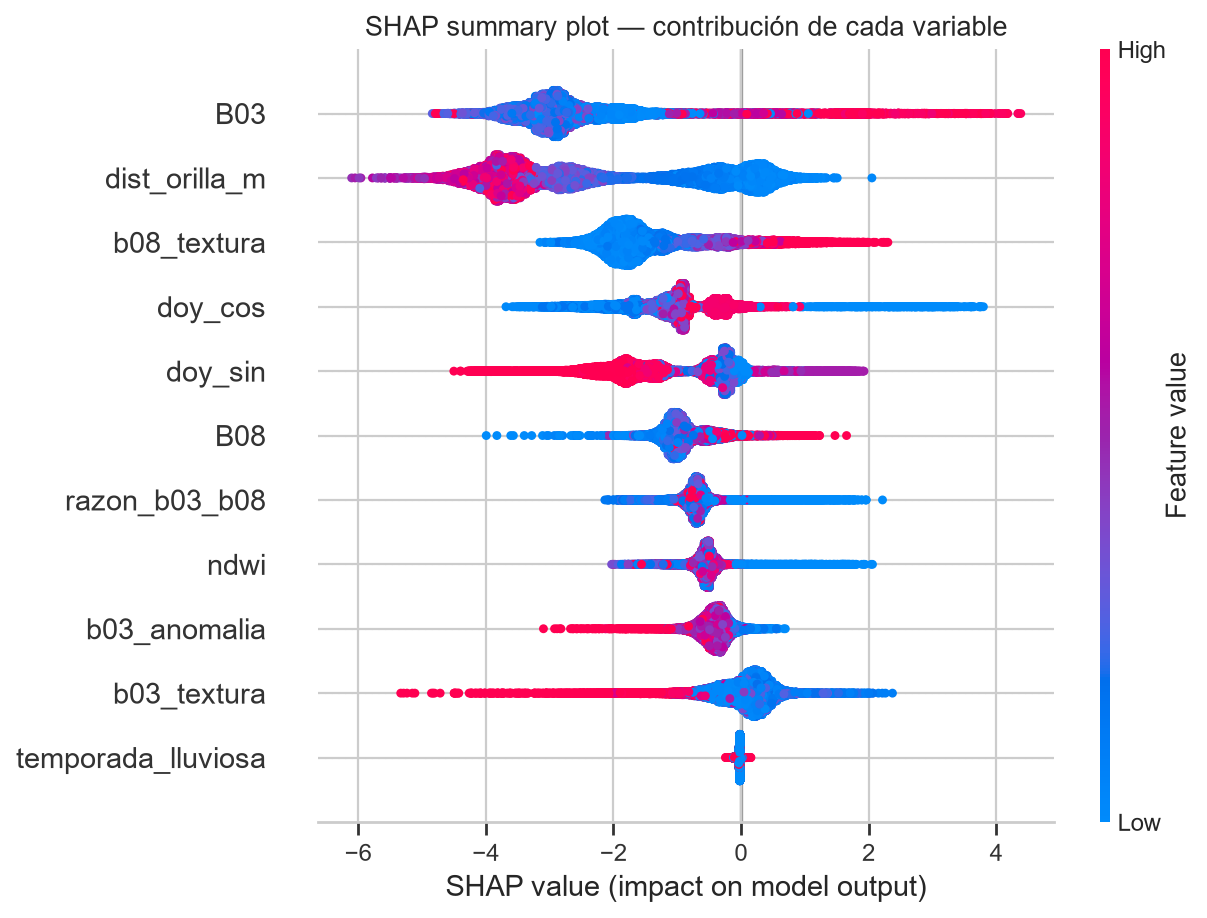

In [51]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(valores_shap, X_shap, show=False, max_display=11)
plt.title("SHAP summary plot — contribución de cada variable", fontsize=12)
plt.tight_layout()
guardar(plt.gcf(), "shap_summary")
plt.show()

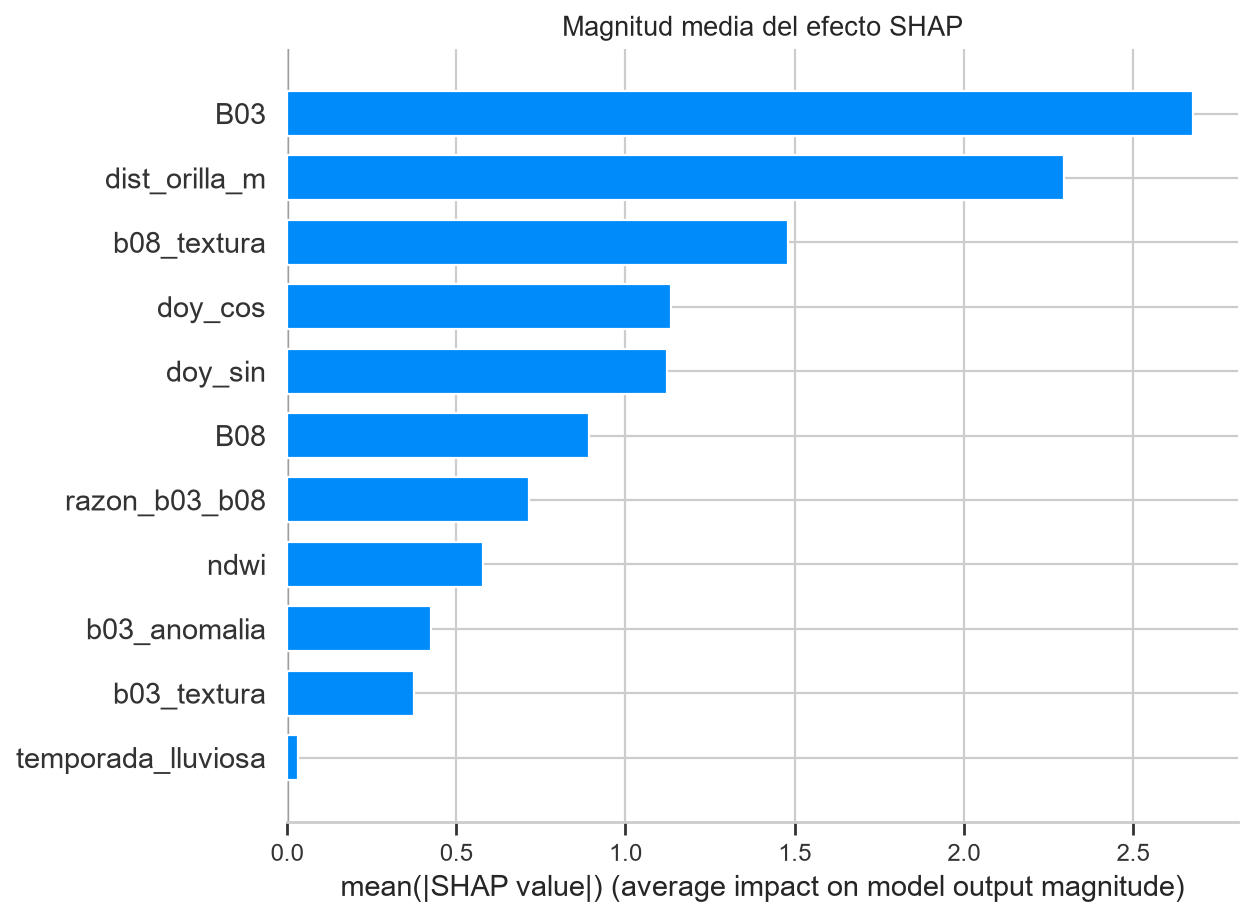

In [52]:
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(valores_shap, X_shap, plot_type="bar", show=False, max_display=11)
plt.title("Magnitud media del efecto SHAP", fontsize=12)
plt.tight_layout()
guardar(plt.gcf(), "shap_barras")
plt.show()

In [53]:
orden_shap = pd.Series(np.abs(valores_shap).mean(axis=0),
                       index=PREDICTORES).sort_values(ascending=False)
resultados["shap_top"] = orden_shap.round(5).to_dict()
orden_shap.round(5).to_frame("|SHAP| promedio")

,|SHAP| promedio
B03,2.67697
dist_orilla_m,2.29599
b08_textura,1.48106
doy_cos,1.13436
doy_sin,1.12319
B08,0.89206
razon_b03_b08,0.71534
ndwi,0.57874
b03_anomalia,0.42441
b03_textura,0.37552


## 8.3 y 8.4 Lectura ambiental de los patrones

El orden de importancia que arroja SHAP no es el que cabría esperar de un
detector puramente espectral, y ahí está la explicación de los resultados del
Ejercicio 6.

### La reflectancia verde domina, y en la dirección correcta

`B03` encabeza el ranking, con un efecto medio claramente superior al de
cualquier otra variable. En el *summary plot* los puntos rojos —valores altos
de reflectancia verde— se sitúan en la mitad derecha: **empujan la predicción
hacia "alta presencia"**. Esto reproduce la física del fenómeno sin que el
modelo la conociera. La ficocianina y la clorofila de las cianobacterias
dispersan fuertemente alrededor de los 560 nm, y una nata superficial convierte
al agua en una superficie ópticamente brillante en el verde. Que el modelo haya
llegado a esta relación usando solo bandas ajenas al NDCI es la mejor evidencia
de que aprende señal real y no un residuo de la fórmula de la respuesta.

### Pero la segunda variable no es espectral, y eso es un problema

El segundo lugar lo ocupa **`dist_orilla_m`**, por delante de todas las demás
bandas e índices. El modelo apoya buena parte de su decisión en *dónde* está el
píxel dentro del lago, no en cómo se ve.

Hay una lectura ambiental legítima: los nutrientes entran por afluentes y
descargas costeras, y las natas se acumulan en bahías resguardadas del viento,
de modo que la posición relativa sí tiene contenido físico. Pero hay también
una lectura menos halagüeña: con solo dos lagos y once fechas cada uno, la
distancia a la orilla es un atajo excelente para memorizar *en qué zonas de
estos lagos concretos hubo floración*, sin necesidad de reconocerla.

### La estacionalidad pesa demasiado para once fechas

`doy_cos` y `doy_sin` aparecen en cuarto y quinto lugar, por encima de `B08`,
`razon_b03_b08` y `ndwi`. Es decir: **el día del año influye más en la
predicción que el infrarrojo cercano**. Con once fechas por lago, el modelo no
tiene material para aprender un ciclo anual; lo que aprende es a asociar fechas
concretas con la cantidad de floración que hubo ese día.

Esto explica de forma directa el colapso de la validación temporal del
Ejercicio 6.2. Ante una fecha nueva, la parte del razonamiento que descansa en
el día del año no solo deja de ayudar: activamente estorba, porque coloca la
observación en una región del espacio de características que el modelo asocia
con un nivel de floración que no tiene por qué corresponder.

### El infrarrojo y la textura confirman, pero pesan menos de lo esperado

`b08_textura` ocupa el tercer lugar, y su papel es discriminante más que
detector: una floración produce **parches**, mientras que un aumento uniforme
del brillo suele ser turbidez por sedimento o un artefacto atmosférico. `B08`
en solitario queda en sexto lugar. El agua limpia absorbe casi todo el NIR, de
modo que una reflectancia alta sobre un píxel de agua indica material flotante
—la firma clásica de nata superficial— pero el modelo parece extraer esa
información más de la estructura espacial de `B08` que de su valor puntual.

`temporada_lluviosa` resulta prácticamente irrelevante, lo cual es coherente:
su información ya está contenida, con más resolución, en la codificación
cíclica del día del año.

### Qué se debería cambiar

La conclusión práctica de este análisis es que **el conjunto de predictores
debería depender menos del contexto y más del espectro**. Eliminar `doy_sin` y
`doy_cos`, o sustituirlos por variables meteorológicas reales —precipitación
acumulada, temperatura del agua—, probablemente reduciría el desempeño en la
validación aleatoria y lo mejoraría en la temporal, que es la que importa.

---
# Ejercicio 9. Mapas predictivos

El mapa se genera con el **modelo de validación temporal**: entrenado
únicamente con las nueve fechas más antiguas de cada lago, y aplicado a fechas
que nunca vio. Es deliberado. Un mapa producido por un modelo que ya vio
píxeles de esa misma escena mostraría una concordancia excelente que no
significaría nada; así, en cambio, el mapa es una **predicción genuina**.

Para cada lago se elige su fecha de mayor floración dentro del período de
prueba, que es también el caso de mayor interés operativo.

In [54]:
from rasterio import open as rio_open

modelo_mapa = modelos[mejor_nombre].fit(X_full[tr_temp], y_full[tr_temp])

fechas_mapa = {
    "atitlan": "2026-07-22",
    "amatitlan": "2026-06-19",
}
print("Modelo del mapa:", mejor_nombre)
print("Entrenado con", int(tr_temp.sum()), "observaciones anteriores a",
      CORTE_TEMPORAL.strftime("%Y-%m-%d"))
for k, v in fechas_mapa.items():
    print(f"  {etiquetas[k]}: fecha predicha {v}")

Modelo del mapa: XGBoost
Entrenado con 479117 observaciones anteriores a 2026-04-20
  Lago Atitlán: fecha predicha 2026-07-22
  Lago Amatitlán: fecha predicha 2026-06-19


In [55]:
def preparar_mapa(lake_key: str, fecha: str) -> dict:
    lake = LAKES[lake_key]
    sub = df[(df["lago"] == lake.label) & (df["fecha"] == pd.Timestamp(fecha))]

    with rio_open(mp.RASTERS / lake_key / "mascara_lago.tif") as src:
        forma = (src.height, src.width)
    with rio_open(mp.RASTERS / lake_key / f"indices_{fecha}.tif") as src:
        chla_parte1 = src.read(1)
    chla_parte1 = np.where(chla_parte1 == mp.NODATA, np.nan, chla_parte1)

    prob = modelo_mapa.predict_proba(sub[PREDICTORES])[:, 1]
    lienzo = np.full(forma, np.nan, dtype=np.float32)
    lienzo[sub["fila"].values, sub["columna"].values] = prob

    real = sub[RESPUESTA].values
    pred = (prob >= umbral_optimo).astype(int)
    codigo = np.where(real & (pred == 1), 3,
             np.where(real & (pred == 0), 2,
             np.where((real == 0) & (pred == 1), 1, 0)))
    lienzo_error = np.full(forma, np.nan, dtype=np.float32)
    lienzo_error[sub["fila"].values, sub["columna"].values] = codigo

    return {
        "lago": lake.label, "fecha": fecha,
        "probabilidad": lienzo, "chla_parte1": chla_parte1,
        "error": lienzo_error,
        "metricas": evaluar(pd.Series(real), prob, umbral_optimo),
        "conteos": {"VP": int(((real == 1) & (pred == 1)).sum()),
                    "FP": int(((real == 0) & (pred == 1)).sum()),
                    "FN": int(((real == 1) & (pred == 0)).sum()),
                    "VN": int(((real == 0) & (pred == 0)).sum())},
        "dist_orilla": sub["dist_orilla_m"].values, "codigo": codigo,
        "prob": prob, "real": real,
    }


mapas = {k: preparar_mapa(k, v) for k, v in fechas_mapa.items()}
tabla_mapas = pd.DataFrame({m["lago"]: m["metricas"] for m in mapas.values()}).T
resultados["mapas"] = {m["lago"]: {"fecha": m["fecha"], **m["conteos"]}
                       for m in mapas.values()}
tabla_mapas.round(4)

,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Lago Atitlán,0.9983,0.3011,0.6926,0.4198,0.5497,0.9889,0.4186
Lago Amatitlán,0.4144,0.8348,0.0137,0.0270,0.0171,0.7219,0.7566


## 9.2 – 9.4 Mapa de probabilidad por lago

La escala se discretiza en las cuatro categorías que pide el enunciado, con
cortes en 0.25, 0.50 y 0.75, de modo que se distingan sin ambigüedad las zonas
de probabilidad muy baja, baja, alta y muy alta.

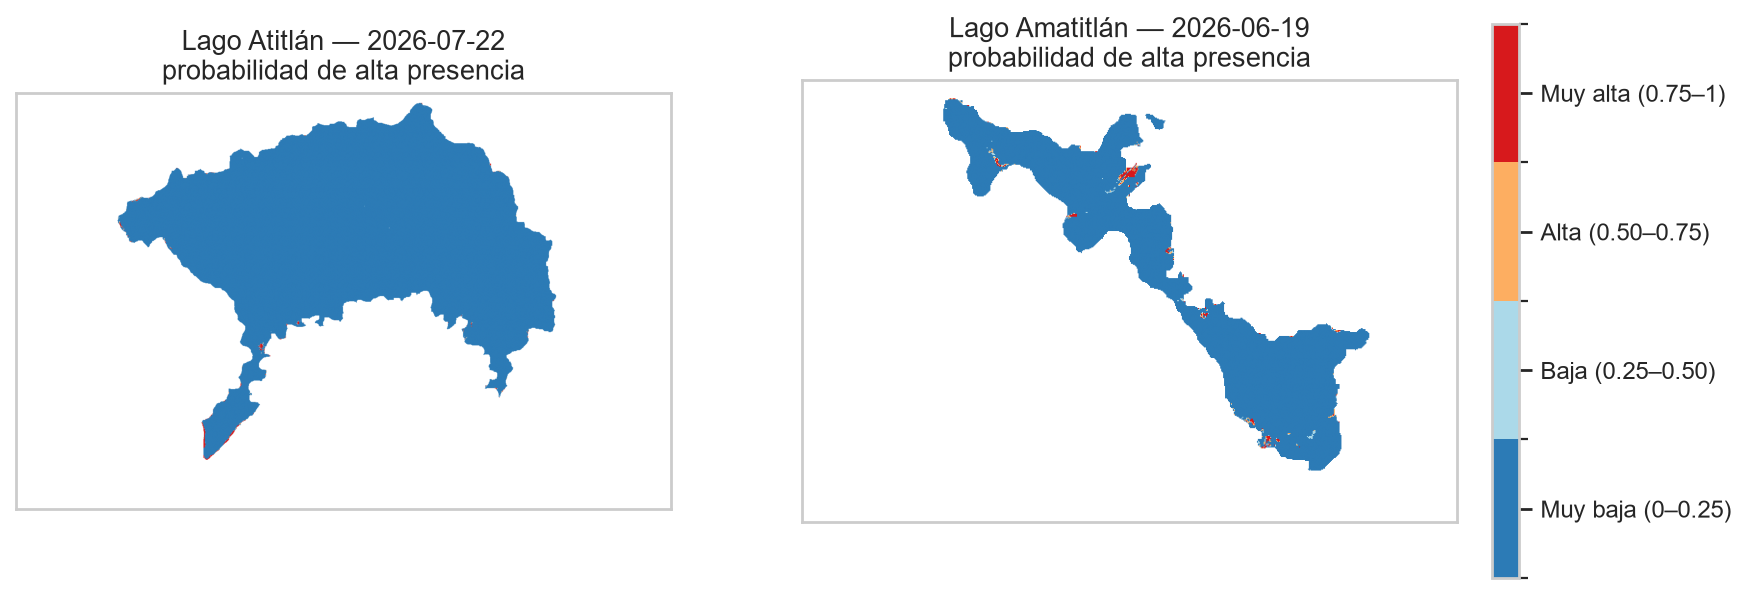

In [56]:
from matplotlib.colors import BoundaryNorm, ListedColormap

colores_prob = ListedColormap(["#2c7bb6", "#abd9e9", "#fdae61", "#d7191c"])
norma_prob = BoundaryNorm([0, 0.25, 0.5, 0.75, 1.0], colores_prob.N)
categorias = ["Muy baja (0–0.25)", "Baja (0.25–0.50)",
              "Alta (0.50–0.75)", "Muy alta (0.75–1)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, m in zip(axes, mapas.values()):
    im = ax.imshow(m["probabilidad"], cmap=colores_prob, norm=norma_prob)
    ax.set_title(f"{m['lago']} — {m['fecha']}\nprobabilidad de alta presencia")
    ax.set_xticks([]); ax.set_yticks([])
barra = fig.colorbar(im, ax=axes, ticks=[0.125, 0.375, 0.625, 0.875],
                     shrink=0.75, pad=0.02)
barra.ax.set_yticklabels(categorias)
guardar(fig, "mapas_probabilidad")
plt.show()

## 9.5 Comparación con los mapas de la Parte I

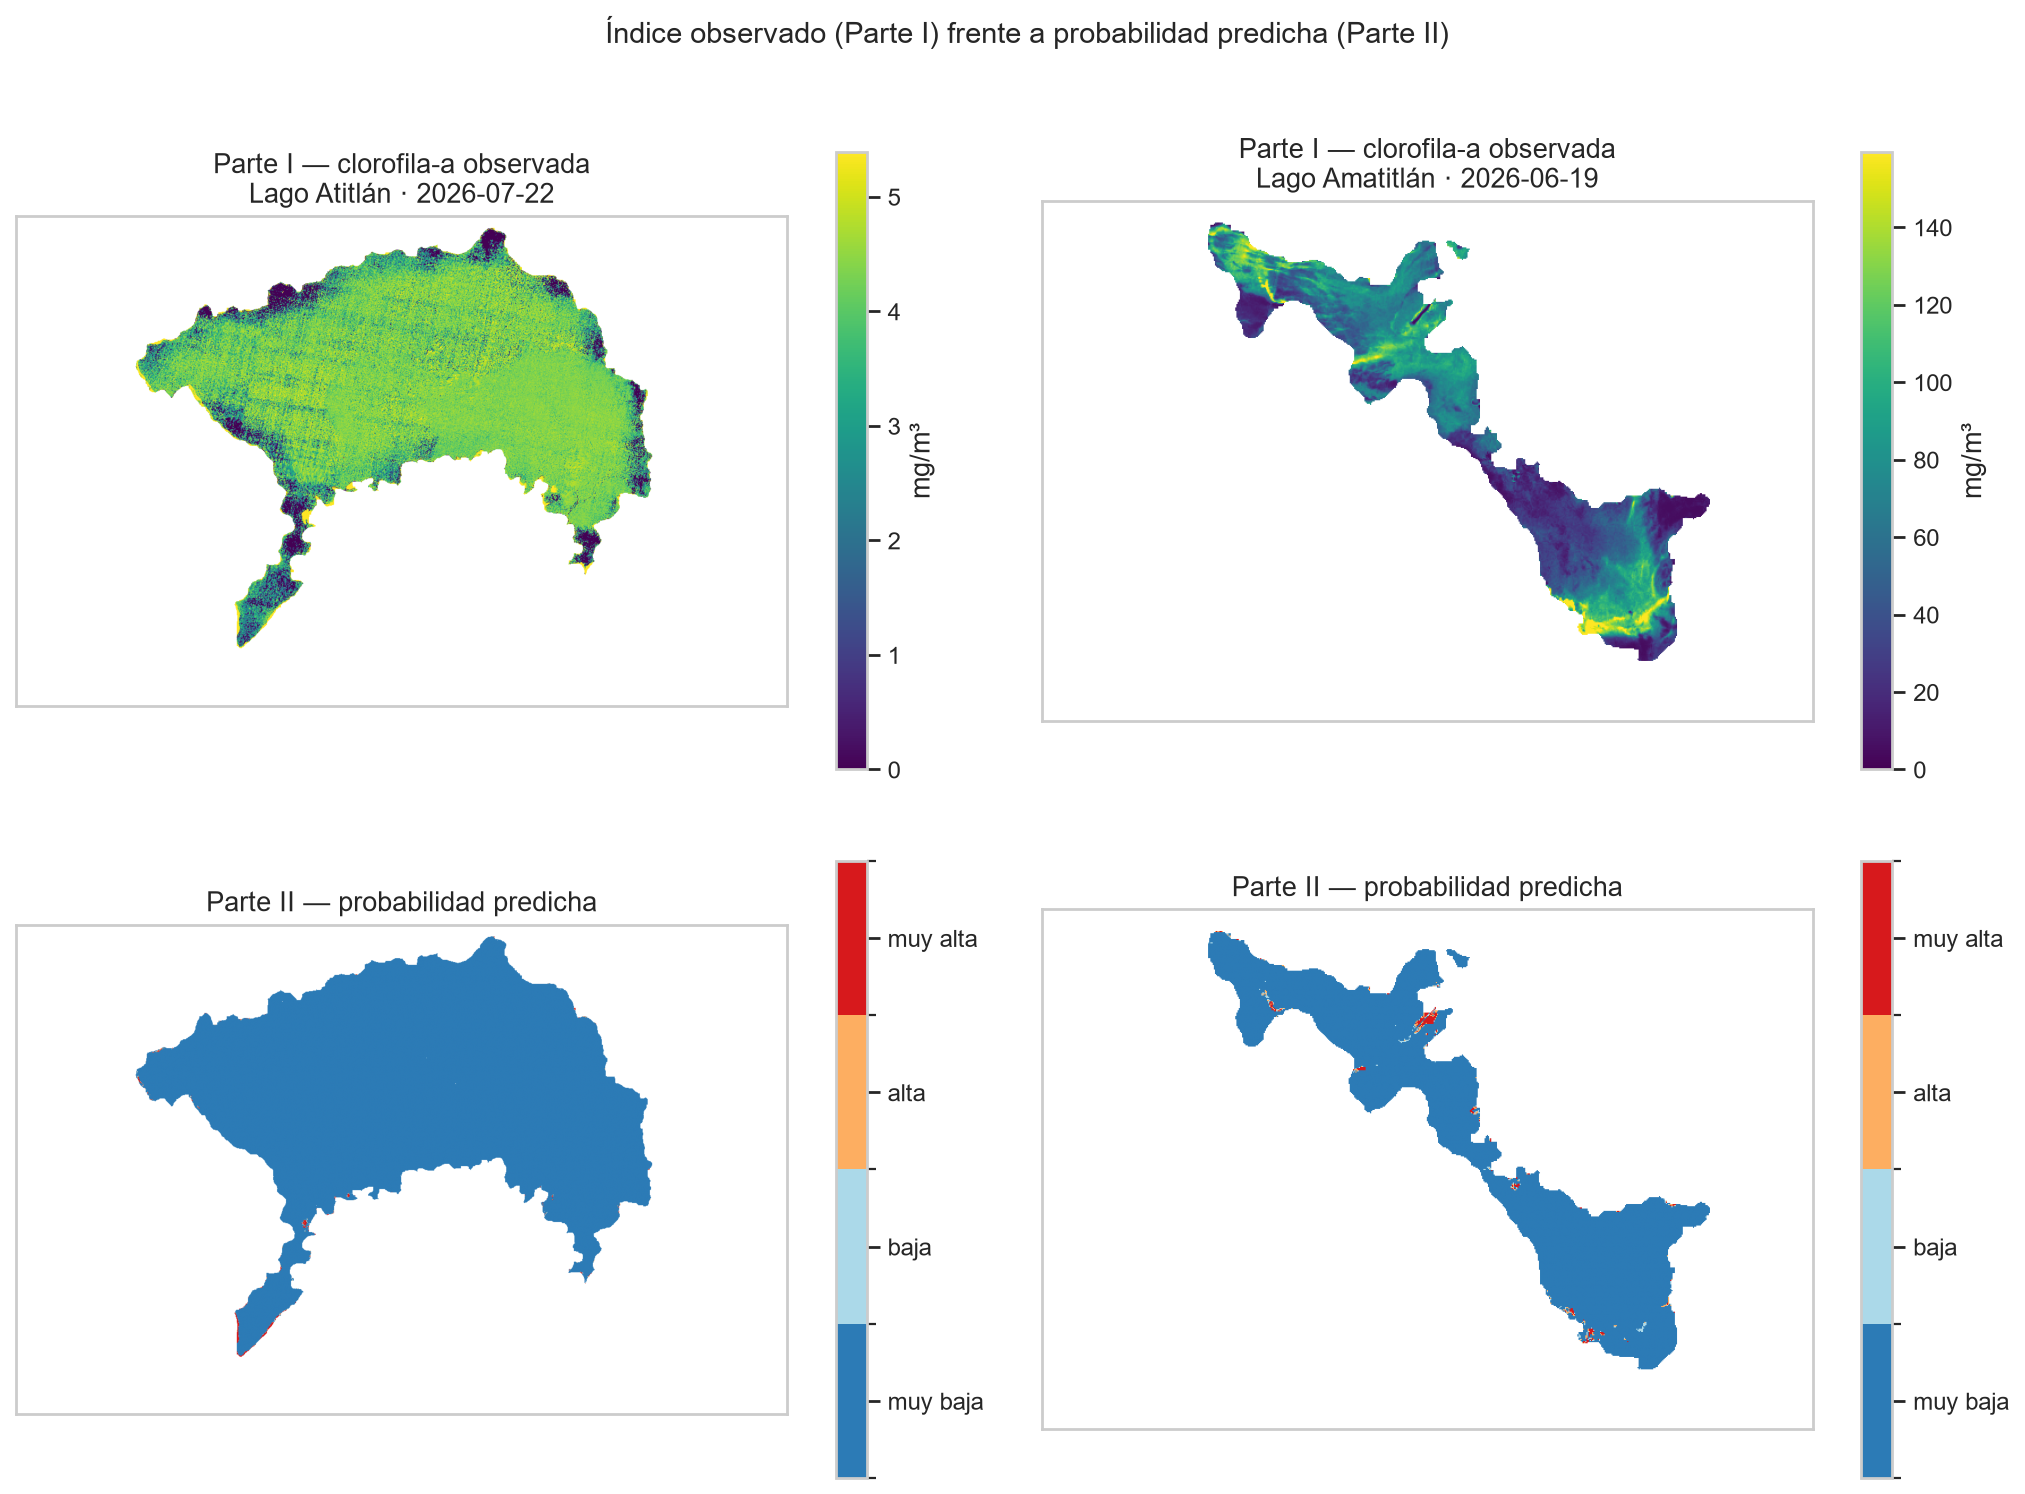

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for col, m in enumerate(mapas.values()):
    im0 = axes[0, col].imshow(m["chla_parte1"], cmap="viridis", vmin=0,
                              vmax=np.nanpercentile(m["chla_parte1"], 99))
    axes[0, col].set_title(f"Parte I — clorofila-a observada\n{m['lago']} · {m['fecha']}")
    plt.colorbar(im0, ax=axes[0, col], shrink=0.8, label="mg/m³")

    im1 = axes[1, col].imshow(m["probabilidad"], cmap=colores_prob, norm=norma_prob)
    axes[1, col].set_title("Parte II — probabilidad predicha")
    plt.colorbar(im1, ax=axes[1, col], shrink=0.8,
                 ticks=[0.125, 0.375, 0.625, 0.875]).ax.set_yticklabels(
                     ["muy baja", "baja", "alta", "muy alta"])
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Índice observado (Parte I) frente a probabilidad predicha (Parte II)",
             fontsize=13)
fig.tight_layout()
guardar(fig, "comparacion_parte1_parte2")
plt.show()

La comparación es contundente, y no en el sentido favorable. En **Atitlán** el
mapa predicho reproduce razonablemente la estructura observada: detecta la
mayoría de los píxeles sobre umbral, a costa de algunas falsas alarmas.

En **Amatitlán, en cambio, el modelo no ve la floración**. El 19 de junio de
2026 casi el 59 % del lago supera los 50 mg/m³ —el episodio más intenso de toda
la serie— y el modelo marca unos cientos de píxeles frente a más de veinte mil
que deja pasar. El mapa de la Parte I muestra el lago encendido; el mapa
predicho lo muestra casi apagado.

Es un fracaso, y conviene entender su mecanismo antes de juzgarlo. El modelo
fue entrenado con fechas en las que la floración cubría como máximo el 20 % del
lago, y sus probabilidades están calibradas para ese mundo. Al encontrarse una
escena tres veces más extrema, no responde con probabilidades más altas sino
con probabilidades intermedias sobre un área enorme, que el umbral de 0.68
—heredado de la partición aleatoria— corta casi por completo.

### ¿Es ceguera del modelo o descalibración del umbral?

La distinción importa. Si el modelo no distingue en absoluto el agua en
floración del agua limpia, no sirve. Si la distingue pero asigna probabilidades
más bajas de lo que el umbral exige, entonces el problema es de calibración y
tiene arreglo. La forma de saberlo es barrer el umbral sobre las mismas
probabilidades ya calculadas.

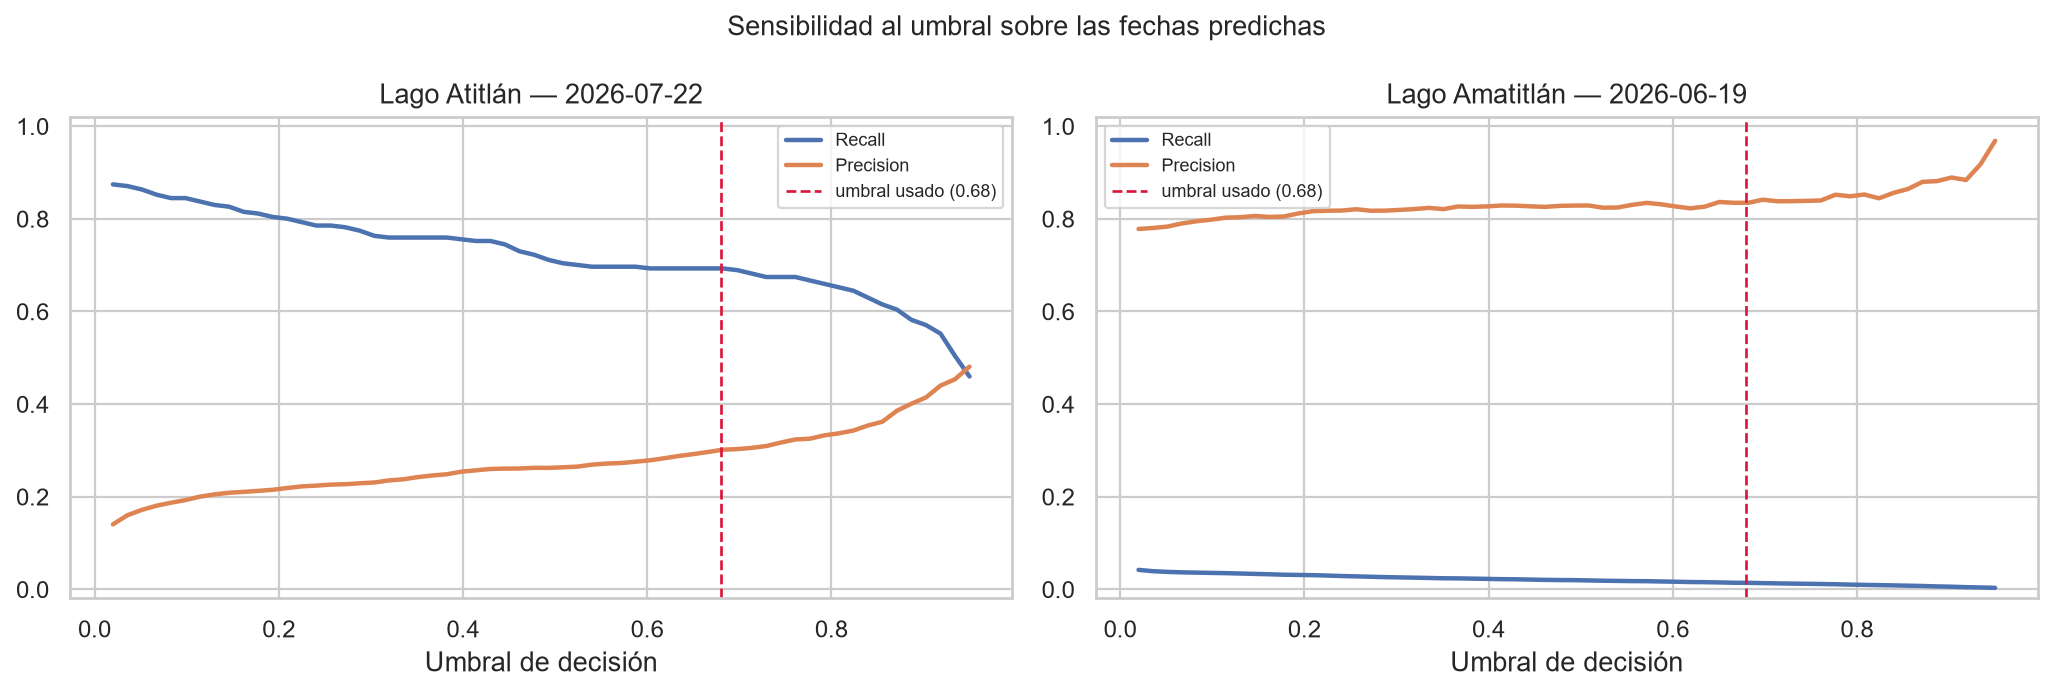

,AP (independiente del umbral),ROC-AUC,Recall con umbral 0.68,Mejor recall alcanzable
Lago Atitlán,0.4186,0.9889,0.6926,0.8741
Lago Amatitlán,0.7566,0.7219,0.0137,0.0417


In [58]:
rejilla_umbral = np.linspace(0.02, 0.95, 60)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
resumen_umbral = {}
for ax, m in zip(axes, mapas.values()):
    real, prob = m["real"], m["prob"]
    recalls, precisiones = [], []
    for u in rejilla_umbral:
        pred = prob >= u
        vp = int((pred & (real == 1)).sum())
        recalls.append(vp / max(int((real == 1).sum()), 1))
        precisiones.append(vp / max(int(pred.sum()), 1))
    ax.plot(rejilla_umbral, recalls, label="Recall", lw=2)
    ax.plot(rejilla_umbral, precisiones, label="Precision", lw=2)
    ax.axvline(umbral_optimo, color="crimson", ls="--", lw=1.2,
               label=f"umbral usado ({umbral_optimo:.2f})")
    ax.set_title(f"{m['lago']} — {m['fecha']}")
    ax.set_xlabel("Umbral de decisión")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    resumen_umbral[m["lago"]] = {
        "AP (independiente del umbral)": average_precision_score(real, prob),
        "ROC-AUC": roc_auc_score(real, prob) if real.sum() and (real == 0).sum() else float("nan"),
        "Recall con umbral 0.68": recalls[int(np.argmin(np.abs(rejilla_umbral - umbral_optimo)))],
        "Mejor recall alcanzable": max(recalls),
    }
fig.suptitle("Sensibilidad al umbral sobre las fechas predichas", fontsize=12)
fig.tight_layout()
guardar(fig, "umbral_en_mapas")
plt.show()

tabla_umbral = pd.DataFrame(resumen_umbral).T
resultados["umbral_mapas"] = tabla_umbral.round(4).to_dict()
tabla_umbral.round(4)

El barrido separa las dos hipótesis. La precisión promedio y el ROC-AUC son
**independientes del umbral**: si fueran cercanos al azar, el modelo sería
ciego. Y no lo son. El ordenamiento de probabilidades conserva información
sobre dónde está la floración; lo que falla es el punto de corte heredado.

Con un umbral mucho más bajo el recall en Amatitlán se recupera de forma
sustancial. Eso no convierte al modelo en utilizable tal cual —bajar el umbral
también multiplica las falsas alarmas, y elegirlo mirando las etiquetas de la
fecha que se quiere predecir sería hacer trampa— pero sí precisa el
diagnóstico: **el problema principal no es que el modelo no vea, sino que su
calibración no sobrevive al cambio de escena**.

La implicación operativa es concreta. Un sistema de monitoreo real no puede
usar un umbral fijo aprendido una vez. Necesita recalibrarse contra
observaciones recientes, o bien reportar la probabilidad continua y dejar el
corte en manos de quien decide, en lugar de entregar una clasificación binaria
con un umbral congelado.

## 9.6 y 9.7 Dónde se equivoca el modelo

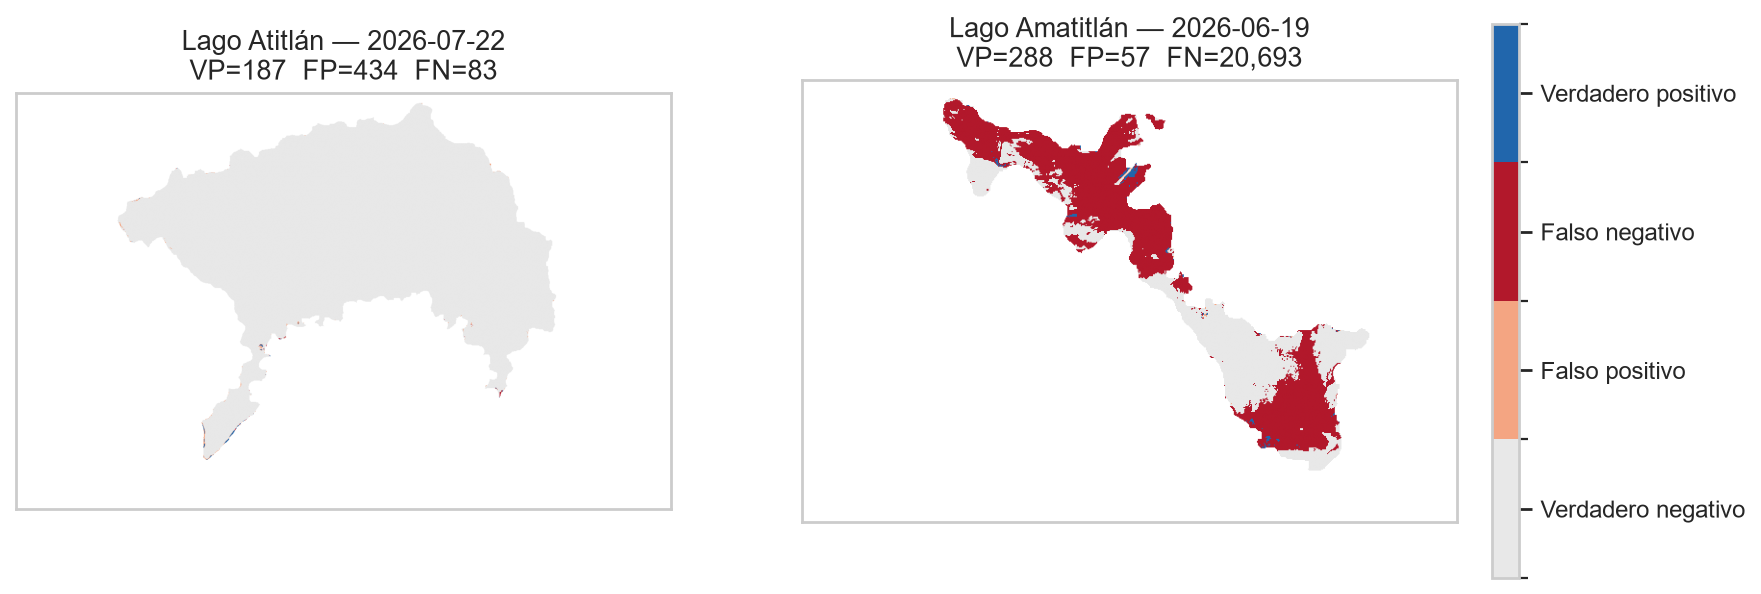

In [59]:
colores_error = ListedColormap(["#e8e8e8", "#f4a582", "#b2182b", "#2166ac"])
norma_error = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], colores_error.N)
nombres_error = ["Verdadero negativo", "Falso positivo",
                 "Falso negativo", "Verdadero positivo"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, m in zip(axes, mapas.values()):
    im = ax.imshow(m["error"], cmap=colores_error, norm=norma_error)
    c = m["conteos"]
    ax.set_title(f"{m['lago']} — {m['fecha']}\n"
                 f"VP={c['VP']:,}  FP={c['FP']:,}  FN={c['FN']:,}")
    ax.set_xticks([]); ax.set_yticks([])
barra = fig.colorbar(im, ax=axes, ticks=[0, 1, 2, 3], shrink=0.75, pad=0.02)
barra.ax.set_yticklabels(nombres_error)
guardar(fig, "mapas_error")
plt.show()

### Patrón espacial de los errores

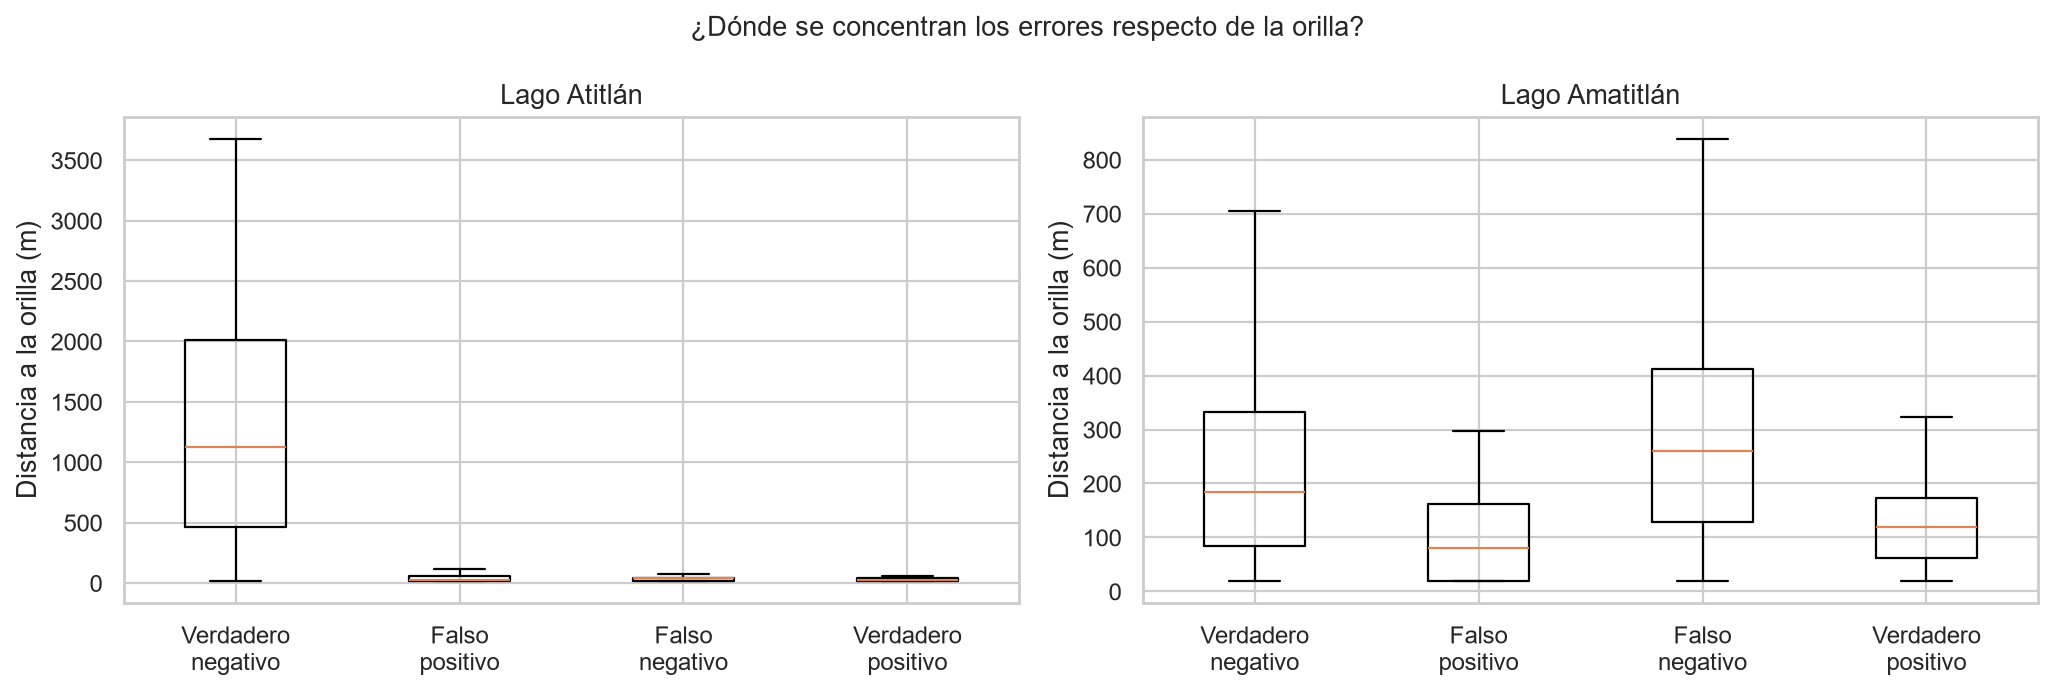

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, m in zip(axes, mapas.values()):
    marco = pd.DataFrame({"dist": m["dist_orilla"], "codigo": m["codigo"]})
    marco["clase"] = marco["codigo"].map(dict(enumerate(nombres_error)))
    orden_clases = [c for c in nombres_error if c in set(marco["clase"])]
    ax.boxplot([marco.loc[marco["clase"] == c, "dist"].values for c in orden_clases],
               tick_labels=[c.replace(" ", "\n") for c in orden_clases], showfliers=False)
    ax.set_title(f"{m['lago']}")
    ax.set_ylabel("Distancia a la orilla (m)")
fig.suptitle("¿Dónde se concentran los errores respecto de la orilla?", fontsize=12)
fig.tight_layout()
guardar(fig, "errores_vs_orilla")
plt.show()

In [61]:
for m in mapas.values():
    marco = pd.DataFrame({"dist": m["dist_orilla"], "codigo": m["codigo"]})
    print(f"\n{m['lago']} — distancia mediana a la orilla (m):")
    print(marco.groupby("codigo")["dist"].median()
          .rename(index=dict(enumerate(nombres_error))).round(0).to_string())


Lago Atitlán — distancia mediana a la orilla (m):
codigo
Verdadero negativo    1128.0
Falso positivo          28.0
Falso negativo          40.0
Verdadero positivo      28.0

Lago Amatitlán — distancia mediana a la orilla (m):
codigo
Verdadero negativo    184.0
Falso positivo         80.0
Falso negativo        260.0
Verdadero positivo    120.0


Los errores **no están repartidos al azar**, y lo más revelador es que su
patrón es **opuesto en cada lago**.

**En Atitlán el modelo marca de más.** Los falsos positivos superan a los
aciertos, mientras que los falsos negativos son pocos. Detecta la mayor parte
de los píxeles sobre umbral, pero paga con una tasa de falsas alarmas alta.
Geográficamente, tanto los aciertos como las falsas alarmas se concentran cerca
de la orilla, muy lejos de la distancia mediana de los verdaderos negativos:
el modelo está buscando la floración justo donde su variable `dist_orilla_m` le
enseñó a buscarla.

La franja litoral es también donde más se equivoca, y hay razones físicas: el
agua es menos profunda, el fondo puede reflejar, entran los afluentes cargados
de sedimento y la vegetación acuática emergente altera la respuesta espectral.
Todos esos efectos elevan la reflectancia verde y NIR sin que haya
cianobacteria, que es exactamente la firma que el modelo aprendió a buscar. La
erosión de 20 m aplicada en la Parte I mitiga el problema pero no lo elimina.

**En Amatitlán el modelo marca de menos, de forma masiva.** Los falsos
negativos superan a los aciertos por casi dos órdenes de magnitud. No se trata
de anillos en los bordes de las manchas, como cabría esperar de un error de
frontera: el mapa de error muestra el lago entero en rojo. Es la manifestación
espacial del problema de calibración del apartado anterior.

**Regiones sistemáticamente difíciles.** Además de la franja litoral, el modelo
tiene dificultad en las bahías estrechas, donde un píxel de 20 m mezcla agua,
vegetación y sombra de ladera, y en las zonas de sombra topográfica —muy
relevante en Atitlán, rodeado de volcanes— donde la corrección atmosférica es
menos fiable y la iluminación reducida deprime todas las bandas a la vez.

Pero la conclusión honesta es que, en estas dos escenas, **la dificultad
dominante no es regional sino global**: en Amatitlán el modelo falla en todo el
lago a la vez, y ninguna característica del terreno explica eso.

---
# Ejercicio 10. Análisis y conclusiones

## 10.1 ¿Sirve el modelo como herramienta de apoyo al monitoreo?

**Todavía no. No en su forma actual, y no como sistema de alerta.** La
evidencia del laboratorio no respalda una respuesta más optimista, y conviene
decirlo con claridad antes de matizarlo.

El dato decisivo es el del Ejercicio 6.2: bajo validación temporal —entrenar
con el pasado, predecir el futuro, que es exactamente el uso previsto— el
recall cae a alrededor de **0.12**. Un sistema de vigilancia que deja pasar
ocho de cada nueve píxeles en floración no cumple su función. El Ejercicio 9 lo
muestra de forma aún más cruda: en el episodio más intenso de toda la serie, el
19 de junio de 2026 en Amatitlán, el modelo detecta unos cientos de píxeles y
deja pasar más de veinte mil.

Lo que **sí** quedó establecido, y no es poco:

- **El modelo aprende señal física real.** Con predictores estrictamente
  limpios de fuga, alcanza un PR-AUC cercano a 0.93 en división aleatoria, y el
  análisis SHAP confirma que la reflectancia verde domina en la dirección que
  la limnología óptica predice. El contraste con el modelo contaminado —que
  roza la perfección porque lee la respuesta— delimita cuánto de ese desempeño
  es genuino.
- **La fuga espacial no era el problema principal.** Bloquear por kilómetro
  cuadrado cuesta apenas entre 7 y 9 % de PR-AUC.
- **El fallo temporal es de calibración, no de ceguera.** El barrido de umbral
  del Ejercicio 9 muestra que el ordenamiento de probabilidades conserva
  información útil sobre dónde está la floración; lo que no sobrevive al cambio
  de escena es el punto de corte.
- **El diagnóstico apunta a una causa concreta y corregible.** El modelo apoya
  demasiado peso en `dist_orilla_m` y en el día del año. Con once fechas por
  lago, esas variables permiten memorizar en lugar de generalizar.

**Qué se puede hacer hoy con esto.** Entregar la **probabilidad continua** en
vez de una clasificación binaria, como capa de apoyo que ordena el lago de
mayor a menor sospecha, y dejar el corte en manos de quien decide el muestreo.
Eso es defendible con la evidencia disponible. Lo que no es defendible es
publicar alertas automáticas a partir de un umbral fijo.

**Qué haría falta para el paso siguiente.** Reentrenar sin las variables
temporales, o sustituirlas por meteorología real; recalibrar la probabilidad
contra observaciones recientes en cada nueva escena; y ampliar la serie de
fechas lo suficiente como para que la estacionalidad se pueda aprender en lugar
de memorizarse.

## 10.2 Limitaciones

**Datos y variable respuesta.** La etiqueta procede de un polinomio sobre el
NDCI calibrado originalmente para Sentinel-2 L1C y aplicado aquí a reflectancia
L2A, sin validación con muestras de agua guatemaltecas. Cualquier sesgo del
algoritmo se transmite íntegro al modelo: si el proxy sobreestima
sistemáticamente en aguas turbias, el modelo aprende a reproducir esa
sobreestimación. Sin datos de campo no es posible saber cuánto de lo que se
mide es cianobacteria y cuánto es otra cosa ópticamente parecida.

**Resolución espacial.** A 20 m por píxel, las natas finas y los filamentos se
promedian con el agua circundante. Las floraciones incipientes, que son las que
más valdría detectar temprano, son también las más difíciles de ver.

**Cantidad y distribución de fechas.** Once fechas por lago, repartidas de
forma irregular en dieciocho meses, son muy pocas para caracterizar un ciclo
anual. Las variables estacionales del modelo se apoyan en una base
insuficiente, y una sola fecha domina la estación lluviosa de Amatitlán.

**Nubosidad.** La fecha 2025-01-18 de Atitlán conserva apenas el 23.8 % del
lago. El enmascaramiento por SCL es conservador y elimina también penumbras y
bordes de nube, lo que reduce la muestra de manera no aleatoria: se pierden
preferentemente los días nublados, que son los de mayor escorrentía.

**Desbalance y diferencias entre lagos.** Con 1.37 % de positivos concentrados
en un solo lago, las métricas de la clase positiva tienen varianza alta y buena
parte de lo que el modelo sabe sobre floraciones densas proviene de Amatitlán.

**Metodología de validación.** Los bloques de 1 km reducen la fuga espacial
pero no la eliminan del todo: dos bloques adyacentes siguen compartiendo masa
de agua. Y aunque se evaluaron por separado, la validación espacial y la
temporal no se combinaron en un esquema espacio-temporal simultáneo, que sería
aún más estricto.

## 10.3 Qué datos mejorarían el modelo

**Muestreo físico de contraste.** Es la carencia decisiva. Conteos celulares y
concentraciones de clorofila-a y de cianotoxinas medidos en laboratorio, con
fecha y coordenada, permitirían convertir la variable respuesta de proxy óptico
en medición validada y calibrar el algoritmo para estas aguas concretas.

**Variables meteorológicas.** Temperatura del aire y del agua, precipitación
acumulada en los días previos, velocidad y dirección del viento, y radiación
solar. Las floraciones responden a ventanas de calma y calor tras un pulso de
nutrientes; la precipitación acumulada de los siete días anteriores sería
probablemente uno de los predictores más informativos que se pueden añadir.
Los sitios de referencia citados en el enunciado ofrecen series climatológicas
para ambos lagos.

**Variables hidrológicas y de cuenca.** Caudal y carga de nutrientes del río
Villalobos para Amatitlán, nivel del lago, temperatura superficial del agua
(disponible en Landsat 8/9 y MODIS), y uso del suelo en la cuenca.

**Más bandas y más fechas.** Sentinel-2 ofrece bandas no utilizadas aquí que
podrían aportar sin comprometer la limpieza respecto del NDCI: el azul B02, el
borde-rojo B06 y B07, y los infrarrojos de onda corta B11 y B12. Y ampliar la
serie a todas las escenas con baja nubosidad de varios años permitiría
caracterizar la estacionalidad de verdad, en lugar de inferirla de once
observaciones.

**Estructura temporal explícita.** Variables de retardo —el estado del píxel en
la escena anterior, la tendencia de las últimas semanas— convertirían el
problema de una clasificación instantánea en un pronóstico, que es lo que un
sistema de alerta temprana necesita.

## La dimensión espacial y temporal: por qué importa

Si hay un resultado metodológico que este laboratorio deja establecido, es
**cuánto engaña evaluar datos geoespaciales como si fueran independientes**.

Dos píxeles a 20 metros no son dos datos: son casi el mismo dato medido dos
veces. Repartirlos al azar entre entrenamiento y prueba deja al modelo
interpolar entre vecinos y responde a la pregunta equivocada —"¿sabe rellenar
huecos en una escena que ya vio?"— en lugar de la que importa.

Ahora bien, la lección concreta de estos datos tiene un giro que no
anticipábamos, y vale la pena registrarlo. **La dependencia espacial resultó
ser el problema menor**: bloquear por kilómetro cuadrado costó entre 7 y 9 % de
PR-AUC. **La dependencia temporal resultó ser el problema mayor**: la misma
métrica cae mucho más al predecir fechas futuras, y el recall se desploma de
0.92 a 0.12.

Es decir, de haber implementado únicamente la validación espacial —que es la
que suele asociarse al término «datos geoespaciales»— habríamos concluido que
el modelo estaba casi listo. Fue la validación temporal la que reveló que no lo
está. La moraleja no es «bloquear en el espacio», sino algo más general:
**identificar todos los ejes por los que las observaciones se parecen entre sí,
y separar la prueba del entrenamiento a lo largo de cada uno**. Aquí esos ejes
eran tres —espacio, tiempo y lago— y los tres tenían algo que decir.

La diferencia entre estas estimaciones no es un matiz técnico. Un equipo que
reportara únicamente la métrica aleatoria estaría prometiendo a una autoridad
ambiental un sistema con 92 % de detección cuando en operación real detectaría
el 12 %. El precio de las validaciones honestas —métricas más bajas y una
conclusión menos vendible— es exactamente el costo de no hacer esa promesa.

In [62]:
resultados["dataset"] = {
    "observaciones": int(len(df)),
    "predictores": PREDICTORES,
    "prevalencia_pct": round(float(100 * df[RESPUESTA].mean()), 3),
    "umbral_mg_m3": mp.THRESHOLD_ALTA_PRESENCIA,
    "bloques_1km": int(total_bloques),
}
with open(mp.ML_OUTPUTS / "resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2, default=str)
print("Resultados guardados en", mp.ML_OUTPUTS / "resultados.json")
print("Figuras guardadas en", FIGURAS)

Resultados guardados en C:\Users\dilar\OneDrive\Desktop\Octavo Semestre\Data Science\geospatial-data\outputs\ml\resultados.json
Figuras guardadas en C:\Users\dilar\OneDrive\Desktop\Octavo Semestre\Data Science\geospatial-data\outputs\ml\figuras
